# Efficient-Coding Cognitive Maps (EC-GCML)
### Combining *goal-directed sampling from cognitive maps* with *efficient coding as an RL objective*, and applying the result to ARC-AGI

---

**Paper 1 — the planner.**
Lin, H., Yang, Y., Zhao, R., Pezzulo, G. & Maass, W. (2026). *Neural sampling from cognitive maps enables goal-directed imagination and planning.* **Nature Machine Intelligence 8, 1045–1065.** Code: `LH-cbicr/GCML`. Builds on the cognitive map learner (CML) of Stöckl, Yang & Maass, *Nat. Commun.* **15**, 2344 (2024).

**Paper 2 — the representation.**
Fang, Z. & Sims, C. R. (2025). *Humans learn generalizable representations through efficient coding.* **Nature Communications 16, 3989.** Code: `fangzefunny/ecpg` (branch `computational_modeling`).

---

The two papers have never been combined, and they fit together at a specific technical joint rather than a vague thematic one. GCML needs an observation embedding $\mathbf{Q}$ and does not learn one in its hardest task. ECPG is *nothing but* a principled way of learning that embedding, and its authors' own Discussion names multi-step planning as the extension they have not tested. Each paper's open problem is the other's contribution.

Everything below is pure NumPy. **No backpropagation anywhere** — every weight update is a delta rule, a Hebbian outer product, or the analytic policy gradient the ECPG paper derives by hand. Runs on a free Colab CPU instance in roughly six to nine minutes.

---
# 1. What each paper actually says

## 1.1 GCML — a cognitive map you can plan in with one matrix–vector product

A cognitive map here is a pair of learned linear embeddings into a common high-dimensional space:

$$\mathbf{s}_t=\mathbf{Q}\mathbf{o}_t \qquad (8)$$
$$\hat{\mathbf{s}}_{t+1}=\mathbf{Q}\mathbf{o}_t+\mathbf{V}\mathbf{a}_t \qquad (10)$$

$\mathbf{Q}$ embeds observations, $\mathbf{V}$ embeds actions, and learning drives the prediction error $\mathbf{s}_{t+1}-\hat{\mathbf{s}}_{t+1}$ to zero with two delta rules:

$$\Delta\mathbf{V}=\eta_v(\mathbf{s}_{t+1}-\hat{\mathbf{s}}_{t+1})\mathbf{a}_t^{\mathsf T}\quad(12)\qquad
\Delta\mathbf{Q}=\eta_q(\hat{\mathbf{s}}_{t+1}-\mathbf{s}_{t+1})\mathbf{o}_t^{\mathsf T}\quad(13)$$

The part that makes planning cheap is the **inverse model** $\mathbf{W}$, learned by a Hebbian rule that maps state differences onto the actions that caused them:

$$\Delta\mathbf{W}=\eta_w\,\mathbf{a}_t(\mathbf{s}_{t+1}-\mathbf{s}_t)^{\mathsf T}\quad(14)\qquad
\mathbf{u}_t=\mathbf{W}(\mathbf{s}^*-\mathbf{s}_t)\quad(15)$$

$\mathbf{W}$ is trained only on *local* one-step differences but applied to the *global* difference to a distant goal. Linearity is what licenses that extrapolation, and it is the paper's central trick: a universal value function for every possible goal, obtained without ever choosing a policy.

Add a learned affordance gate $\mathbf{G}$ (eq. 17) and Gaussian noise, and the deterministic CML becomes the *generative* GCML:

$$\mathbf{e}_t=\hat{\mathbf{g}}_t\odot(\mathbf{u}_t+\boldsymbol{\epsilon})\quad(18)\qquad
\mathbf{a}_t=\mathrm{WTA}(\mathbf{e}_t)\quad(19)\qquad
\hat{\mathbf{s}}_{t+1}=\hat{\mathbf{s}}_t+\mathbf{V}\mathbf{a}_t\quad(20)$$

One plan becomes a *distribution* over plans clustered near the optimum.

## 1.2 ECPG — reward maximisation minus the cost of the representation

Fang & Sims break a policy into an encoder and a decoder,

$$\pi(a\mid s)=\sum_z \underbrace{\psi(z\mid s)}_{\mathrm{softmax}(f(s)\theta)}\;\underbrace{\rho(a\mid z)}_{\mathrm{softmax}(\phi)}$$

and optimise the classical RL objective **augmented with an information cost**:

$$\max_{\psi,\rho}\;\mathbb{E}_{\psi,\rho}\big[r(s_t,a_t)-b\big]\;-\;\lambda\,I^{\psi}(S;Z) \qquad (2)$$

$\lambda$ is the *simplicity parameter*. At $\lambda=0$ the model reduces to a plain cascade policy gradient (CAPG). As $\lambda\to\infty$ every stimulus collapses onto one latent state. The claim of the paper is that the interesting behaviour — generalisation — lives strictly between those endpoints, and that humans sit there.

The analytic gradients (their supplement, transcribed from `utils/model.py`) are

$$s_\theta = u\,\rho(a\mid Z)^{\mathsf T}-\lambda\big(\log\psi(Z\mid s)-\log p(Z)\big),\qquad
g_\theta=-f^{\mathsf T}\!\left[\psi\odot\big(s_\theta-\psi s_\theta^{\mathsf T}\big)\right]$$

with $u=r-b$ and $b=0.5$. The $\lambda$ term is the whole story: it pushes $\psi(z\mid s)$ towards the marginal $p(z)$, which merges any two stimuli that call for the same action. That merger *is* generalisation — a stimulus never paired with an action inherits the answer from whatever it got merged with.

---
# 2. What the repositories show that the papers do not

I read both codebases before writing this notebook, and four things in them materially changed the design. Three of them contradict a natural reading of the corresponding paper.

### 2.1 GCML's compositional task does not learn $\mathbf{Q}$ at all

`gcml_tiling.ipynb` builds its encoder as a fixed convolution with no learnable parameters:

```python
self.q_conv_.weight.data = torch.tensor([[[[0.,1.,0.],[1.,0.,1.],[0.,1.,0.]]]])
```

Equation (13) is never applied in the hardest task in the paper. For silhouettes a hand-designed $\mathbf{Q}$ is reasonable. For ARC, *designing that encoder is the entire problem*.

### 2.2 In the tiling notebook $\mathbf{W}$ is assigned, not learned

The graph notebook uses the paper's delta rule. The tiling notebook does not:

```python
model.V[action, :] += 0.01 * predict_error
model.W[action, :] = o_next - o_pre        # direct assignment
```

Two different rules under one equation number. I use the delta form (eq. 14), because assignment cannot average over the many contexts in which an ARC action occurs.

### 2.3 GCML's tiling planner is closed-loop, and its noise is *relative*

```python
utility += torch.randn_like(utility) * noise_param["sigma"] * torch.max(utility)
```

The noise is scaled by the largest utility, not absolute. Since utilities shrink as the map converges, this keeps the exploration/exploitation ratio roughly fixed. The planner also queries `env.gain_affordance_vector` — ground truth — so the learned gate $\mathbf{G}$ is unused there. I reproduce both choices and flag where $\mathbf{G}$ matters.

### 2.4 ECPG ships two gradients, and pretrains its encoder

`utils/model.py` carries `ecPG_sim` (analytic) and `ecPG` (fitting), differing only in whether $\lambda$ divides the reward term. The repo's own docstring says the analytic version *"is more consistent with the objective function. It is easy to illustrate the model behaviors with varying λ"*, and that the fitting version exists only to decorrelate $\alpha_\psi$ from $\lambda$ during estimation. We vary $\lambda$ rather than fit it, so the analytic form is the correct choice.

Also, `_init_agent` loads `exp1_ecpg_weight.pkl`: **the encoder is pretrained** to ~99% discrimination among the stimuli before the experiment starts, so every model begins from the same near one-to-one encoding, and the 1% shortfall is deliberate — it models perceptual noise and prevents a vanishing gradient. Skipping this makes $\lambda$ look far more powerful than it is, because an untrained encoder is *already* partly collapsed. We reproduce it.

---
# 3. The combination, and why ARC is the right test

## 3.1 Each paper repairs the other's specific failure

**GCML's failure on ARC.** $\mathbf{Q}$ must turn a grid into a point in the map. Learn it with eq. (13) on dense observations and it has a degenerate fixed point: every grid maps to the same state, prediction error is identically zero, and the map carries no information. Freeze it and you must design it by hand — which for ARC is the whole task.

**ECPG's failure on ARC.** ECPG is a *one-step bandit*. It chooses a single action for a single stimulus and stops. ARC needs composition. Fang & Sims say so themselves: they *"plan to extend the current framework in future research to more complex task settings, such as multi-step Markov Decision Processes,"* and ask whether *"complex human behaviors like planning"* follow. This notebook is one answer to that question.

## 3.2 The joint

$$\underbrace{\mathbf{o}\;\xrightarrow{\;f\;}\;\text{features}\;\xrightarrow{\;\psi\;}\;\mathbf{z}}_{\text{ECPG: what to distinguish}}\;\xrightarrow{\;\mathbf{R}\;}\;\underbrace{\mathbf{s}\in\mathbb{R}^{d}\;\xrightarrow{\;\mathbf{V},\mathbf{W},\mathbf{G}\;}\;\text{plans}}_{\text{GCML: where to go}}$$

The composite $\mathbf{Q}=\mathbf{R}\circ\psi$ is GCML's observation embedding, learned — but learned under eq. (2) rather than eq. (13). $\mathbf{R}$ is a fixed norm-preserving random lift into the high-dimensional coding space where a brain would compute; it adds no capacity, and saying so plainly matters, because the map's *intrinsic* dimension is $n_Z$, which is exactly the quantity efficient coding controls.

Action selection then carries both papers' contributions in one line:

$$\mathbf{e}_t=\hat{\mathbf{g}}_t\odot\big(\underbrace{\mathbf{W}(\mathbf{s}^*-\hat{\mathbf{s}}_t)}_{\text{GCML: towards \emph{this} goal}}+\;\beta\underbrace{\log\rho(a\mid\mathbf{z}_t)}_{\text{ECPG: what tends to work}}+\;\boldsymbol{\epsilon}\big)$$

$\beta=0$ recovers plain GCML. The two terms are genuinely complementary: $\mathbf{W}$ is goal-conditional and reward-blind; $\rho$ is reward-shaped and goal-blind.

## 3.3 Three predictions

**P1 — compression produces functional generalisation over grids.** Untrained ARC stimulus–action associations should be answered above chance at moderate $\lambda$, at chance for $\lambda=0$, and *below* chance when $\lambda$ is large enough to over-merge. An inverted U, not a monotone benefit.

**P2 — efficient coding selects the reward-relevant grid feature.** Manipulate whether colour predicts the correct transformation. Perturbation-based feature importance should track the manipulation for ECPG and not for $\lambda=0$.

**P3 — the compressed code is a usable cognitive map.** With $\mathbf{Q}=\mathbf{R}\circ\psi$, GCML's forward model, inverse model and sampling planner should work, and the ECPG decoder prior should add something the inverse model does not have.

Each prediction has a failure mode that would show up as a specific number, and I report the ones that did.

---
# 4. Setup

In [ ]:
import numpy as np, json, os, time, glob, subprocess, heapq, itertools
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True, linewidth=140)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})
print("numpy", np.__version__)

ARC_CMAP = np.array([
    [0,0,0],[0,116,217],[255,65,54],[46,204,64],[255,220,0],
    [170,170,170],[240,18,190],[255,133,27],[127,219,255],[135,12,37]], dtype=np.uint8)

def show_grid(g, ax=None, title=None):
    g = np.asarray(g)
    if ax is None:
        _, ax = plt.subplots(figsize=(1.7, 1.7))
    ax.imshow(ARC_CMAP[np.clip(g, 0, 9)], interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(True); s.set_color("0.6")
    if title:
        ax.set_title(title, fontsize=8)
    return ax

def show_pairs(pairs, maxn=4, titles=("in","out")):
    pairs = pairs[:maxn]
    fig, axs = plt.subplots(2, len(pairs), figsize=(1.5*len(pairs), 3.2), squeeze=False)
    for j,(a,b) in enumerate(pairs):
        show_grid(a, axs[0][j], titles[0] if j==0 else None)
        show_grid(b, axs[1][j], titles[1] if j==0 else None)
    plt.tight_layout(); plt.show()

numpy 2.0.2


---
# 5. Core knowledge: grids and object parsing

Both papers permit a domain prior underneath the learned representation. GCML gives its tiling task a hand-designed encoder; ECPG hands its model a feature embedding of shape, colour and appendage rather than raw pixels. So an object parser is within the rules of both — what matters is that everything *downstream* of it is learned.

In [ ]:
"""Core knowledge: ARC grids, object parsing, and the FACTORISED feature code
that the ECPG encoder consumes.  Pure numpy."""
import numpy as np
from collections import Counter

NCOLORS = 10

# ---------------------------------------------------------------- grids

def as_grid(x):
    g = np.asarray(x, dtype=np.int8)
    assert g.ndim == 2, f"grid must be 2-D, got {g.shape}"
    return g

def grid_eq(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return a.shape == b.shape and bool(np.array_equal(a, b))

def background_color(g):
    return int(np.argmax(np.bincount(np.asarray(g).ravel(), minlength=NCOLORS)))

def palette(g):
    return sorted(set(np.asarray(g).ravel().tolist()))

# ---------------------------------------------------------------- objects

class Obj:
    __slots__ = ("mask", "color", "top", "left", "h", "w", "size", "cy", "cx")
    def __init__(self, mask, color, top, left):
        self.mask, self.color, self.top, self.left = mask, color, top, left
        self.h, self.w = mask.shape
        self.size = int(mask.sum())
        ys, xs = np.nonzero(mask)
        self.cy = top + float(ys.mean()) if self.size else top
        self.cx = left + float(xs.mean()) if self.size else left

    def normshape(self, k=5):
        """Shape resampled to k x k, colour-free."""
        m = self.mask.astype(float)
        if m.shape == (k, k):
            return m
        ys = (np.arange(k) * m.shape[0] / k).astype(int).clip(0, m.shape[0] - 1)
        xs = (np.arange(k) * m.shape[1] / k).astype(int).clip(0, m.shape[1] - 1)
        return m[np.ix_(ys, xs)]


def _components(binary, diag=False):
    H, W = binary.shape
    seen = np.zeros((H, W), bool)
    nb = [(-1,0),(1,0),(0,-1),(0,1)] + ([(-1,-1),(-1,1),(1,-1),(1,1)] if diag else [])
    out = []
    for i in range(H):
        for j in range(W):
            if binary[i, j] and not seen[i, j]:
                stack, cells = [(i, j)], []
                seen[i, j] = True
                while stack:
                    y, x = stack.pop()
                    cells.append((y, x))
                    for dy, dx in nb:
                        u, v = y + dy, x + dx
                        if 0 <= u < H and 0 <= v < W and binary[u, v] and not seen[u, v]:
                            seen[u, v] = True
                            stack.append((u, v))
                out.append(cells)
    return out


def objects_of(g, mode="color4", max_objects=12):
    """Parse a grid into objects.  Spelke-style core knowledge, allowed by both
    papers as a domain prior that sits *below* the learned representation."""
    g = as_grid(g)
    bg = background_color(g)
    objs = []
    if mode in ("color4", "color8"):
        diag = mode.endswith("8")
        for c in palette(g):
            if c == bg:
                continue
            for cells in _components(g == c, diag):
                ys = [y for y, _ in cells]; xs = [x for _, x in cells]
                t, l, b, r = min(ys), min(xs), max(ys), max(xs)
                m = np.zeros((b - t + 1, r - l + 1), bool)
                for y, x in cells:
                    m[y - t, x - l] = True
                objs.append(Obj(m, c, t, l))
    else:  # "any": ignore colour, one blob per connected non-bg region
        for cells in _components(g != bg, mode.endswith("8")):
            ys = [y for y, _ in cells]; xs = [x for _, x in cells]
            t, l, b, r = min(ys), min(xs), max(ys), max(xs)
            m = np.zeros((b - t + 1, r - l + 1), bool)
            cc = Counter()
            for y, x in cells:
                m[y - t, x - l] = True
                cc[int(g[y, x])] += 1
            objs.append(Obj(m, cc.most_common(1)[0][0], t, l))
    objs.sort(key=lambda o: (-o.size, o.top, o.left))
    return objs[:max_objects]


# ------------------------------------------------- the factorised feature code
#
# ECPG's Experiment 2 encodes each stimulus as D feature dimensions, each a
# one-hot over K values, concatenated (there: 3 dims x 5 values = 15-d).  The
# factorisation is not cosmetic: the perturbation-based importance measure
# (their Fig. 4A/B) perturbs ONE dimension at a time, so the dimensions have to
# exist as separate blocks.  We keep the same shape for ARC grids.

FEATURE_DIMS = [
    "n_objects",        # how many objects
    "n_colors",         # size of the palette
    "dominant_shape",   # shape class of the largest object
    "symmetry",         # which symmetry the grid has
    "aspect",           # H vs W of the grid
    "size_spread",      # are the objects equal-sized or not
    "dominant_color",   # which colour covers most non-background cells
    "density",          # fraction of non-background cells
]
K = 5                                  # values per dimension
N_DIMS = len(FEATURE_DIMS)
N_FEAT = N_DIMS * K


def _bin(v, edges):
    """Index of v among edges, clipped into [0, K-1]."""
    return int(min(np.searchsorted(edges, v, side="right"), K - 1))


def _shape_class(o):
    if o is None:
        return 0
    h, w, s = o.h, o.w, o.size
    if s == h * w:
        if h == w:
            return 1                       # square block
        return 2                           # rectangle
    if h == 1 or w == 1:
        return 3                           # line
    return 4                               # irregular


def _symmetry_class(g):
    lr = np.array_equal(g, g[:, ::-1])
    ud = np.array_equal(g, g[::-1, :])
    if lr and ud:
        return 3
    if lr:
        return 1
    if ud:
        return 2
    if g.shape[0] == g.shape[1] and np.array_equal(g, g.T):
        return 4
    return 0


def feature_values(g, objs=None):
    """Return the integer value (0..K-1) of each feature dimension."""
    g = as_grid(g)
    if objs is None:
        objs = objects_of(g)
    bg = background_color(g)
    H, W = g.shape
    nz = int((g != bg).sum())
    big = objs[0] if objs else None

    cc = Counter()
    for o in objs:
        cc[o.color] += o.size
    dom = cc.most_common(1)[0][0] if cc else bg

    sizes = [o.size for o in objs]
    spread = (np.std(sizes) / max(np.mean(sizes), 1e-9)) if len(sizes) > 1 else 0.0

    return np.array([
        _bin(len(objs),          [.5, 1.5, 2.5, 3.5]),
        _bin(len(palette(g)),    [1.5, 2.5, 3.5, 4.5]),
        _shape_class(big),
        _symmetry_class(g),
        _bin(W / max(H, 1),      [0.75, 0.99, 1.01, 1.5]),
        _bin(spread,             [1e-9, .2, .5, 1.0]),
        _bin(dom,                [1.5, 3.5, 5.5, 7.5]),
        _bin(nz / max(H * W, 1), [.1, .25, .5, .75]),
    ], dtype=int)


def embed(g, objs=None):
    """f(o): concatenated one-hots, shape (1, N_FEAT).  This is ECPG's `embed`."""
    v = feature_values(g, objs)
    f = np.zeros((N_DIMS, K))
    f[np.arange(N_DIMS), v] = 1.0
    return f.reshape(1, -1)


def embed_many(grids):
    return np.vstack([embed(g) for g in grids])

---
# 6. The factorised feature code

This is where ECPG's Experiment 2 architecture does real work. Their stimuli are encoded as $D$ feature dimensions, each a one-hot over $K$ values, concatenated. The factorisation is not cosmetic: the perturbation-based importance measure perturbs **one dimension at a time**, so the dimensions have to exist as separate blocks. Section 13 depends on it entirely.

Eight dimensions, five values each, 40-d input. Two design points worth stating:

* **`dominant_color` is one dimension among eight, not a privileged one.** Whether it matters is something the model has to discover, and §13 manipulates the answer.
* **Some dimensions are deliberately near-constant** on the families used below (`symmetry`, `n_colors`). They are the distractors. A model that cannot ignore them will look busy and learn nothing.

8 dimensions x 5 values = 40-d input

  0  n_objects
  1  n_colors
  2  dominant_shape
  3  symmetry
  4  aspect
  5  size_spread
  6  dominant_color
  7  density

example grid -> feature values: [2 2 1 0 3 2 1 1]
embed shape: (1, 40)  (one 1 per dimension)


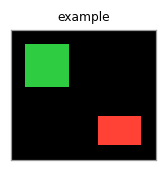

In [ ]:
print(f"{N_DIMS} dimensions x {K} values = {N_FEAT}-d input\n")
for i, d in enumerate(FEATURE_DIMS):
    print(f"  {i}  {d}")

_rng = np.random.default_rng(0)
_g = np.zeros((9,10), dtype=np.int8); _g[1:4,1:4] = 3; _g[6:8,6:9] = 2
print("\nexample grid -> feature values:", feature_values(_g))
print("embed shape:", embed(_g).shape, " (one 1 per dimension)")
show_grid(_g, title="example"); plt.show()

---
# 7. The action repertoire

49 deterministic grid transformations. Wherever an action refers to a colour it does so by **frequency rank** (`->rank0` = "whatever colour is commonest here"), never by absolute index, so an action learned on one palette means the same thing on another. This is the compositional-coding leg of GCML, which gives "remove building block $b$ at position $p$" a code assembled from parts rather than an arbitrary index.

`affordance(g)` returns GCML's ground-truth gate $\mathbf{g}_t$ — the target of eq. (17). Note that a no-op counts as *not* affordable: an action that leaves the grid unchanged is not a move.

In [ ]:
"""The action repertoire.  Every action is a deterministic grid -> grid map or
None (not executable here).  `affordance` returns GCML's ground-truth gating
vector g_t (eq. 17's target)."""
import numpy as np
from collections import Counter


# ------------------------------------------------------------ selectors
def _sel(g, kind):
    objs = objects_of(g, mode="color4")
    if not objs:
        return []
    if kind == "all":
        return objs
    if kind == "largest":
        return [max(objs, key=lambda o: o.size)]
    if kind == "smallest":
        return [min(objs, key=lambda o: o.size)]
    if kind in ("rarest_color", "commonest_color"):
        cc = Counter()
        for o in objs:
            cc[o.color] += o.size
        c = (min if kind == "rarest_color" else max)(cc, key=lambda k: cc[k])
        return [o for o in objs if o.color == c]
    if kind == "odd_shape":
        sig = Counter(tuple(o.normshape(4).round(2).ravel()) for o in objs)
        for o in objs:
            if sig[tuple(o.normshape(4).round(2).ravel())] == 1:
                return [o]
        return []
    return objs


def _paint(g, objs, color):
    out = g.copy()
    for o in objs:
        ys, xs = np.nonzero(o.mask)
        out[o.top + ys, o.left + xs] = color
    return out


def _erase(g, objs):
    return _paint(g, objs, background_color(g))


def _rank_color(g, rank):
    """Colour with the given frequency rank among non-background colours.
    A RELATIONAL reference: survives an arbitrary relabelling of the palette."""
    bg = background_color(g)
    cnt = Counter(int(v) for v in g.ravel() if v != bg)
    if not cnt:
        return None
    order = [c for c, _ in cnt.most_common()]
    return order[rank] if rank < len(order) else None


# ------------------------------------------------------------ the actions
def _geo(name):
    f = {"identity": lambda g: g,
         "fliplr":   lambda g: g[:, ::-1],
         "flipud":   lambda g: g[::-1, :],
         "rot90":    lambda g: np.rot90(g, 1),
         "rot180":   lambda g: np.rot90(g, 2),
         "rot270":   lambda g: np.rot90(g, 3),
         "transpose": lambda g: g.T}[name]
    return lambda g: np.ascontiguousarray(f(g)).astype(np.int8)


def _crop_content(g):
    bg = background_color(g)
    ys, xs = np.nonzero(g != bg)
    if len(ys) == 0:
        return None
    return np.ascontiguousarray(g[ys.min():ys.max() + 1, xs.min():xs.max() + 1])


def _crop_obj(g, kind):
    objs = _sel(g, kind)
    if not objs:
        return None
    o = objs[0]
    return np.ascontiguousarray(g[o.top:o.top + o.h, o.left:o.left + o.w])


def _tile(g, ky, kx):
    if g.shape[0] * ky > 30 or g.shape[1] * kx > 30:
        return None
    return np.ascontiguousarray(np.tile(g, (ky, kx)))


def _mirror_cat(g, axis):
    if axis == 0:
        if g.shape[0] * 2 > 30:
            return None
        return np.ascontiguousarray(np.concatenate([g, g[::-1, :]], 0))
    if g.shape[1] * 2 > 30:
        return None
    return np.ascontiguousarray(np.concatenate([g, g[:, ::-1]], 1))


def _gravity(g, direction):
    bg = background_color(g)
    out = np.full_like(g, bg)
    if direction in ("down", "up"):
        for j in range(g.shape[1]):
            col = [v for v in g[:, j] if v != bg]
            if direction == "down":
                out[g.shape[0] - len(col):, j] = col
            else:
                out[:len(col), j] = col
    else:
        for i in range(g.shape[0]):
            row = [v for v in g[i, :] if v != bg]
            if direction == "right":
                out[i, g.shape[1] - len(row):] = row
            else:
                out[i, :len(row)] = row
    return out


def _keep_only(g, kind):
    objs = objects_of(g, mode="color4")
    keep = _sel(g, kind)
    drop = [o for o in objs if o not in keep]
    return _erase(g, drop) if drop else g


def _recolor_rank(g, kind, rank):
    c = _rank_color(g, rank)
    objs = _sel(g, kind)
    if c is None or not objs:
        return None
    return _paint(g, objs, c)


def _swap_two_ranks(g):
    a, b = _rank_color(g, 0), _rank_color(g, 1)
    if a is None or b is None:
        return None
    out = g.copy()
    out[g == a] = b
    out[g == b] = a
    return out


def _border(g, rank):
    c = _rank_color(g, rank)
    if c is None or min(g.shape) < 3:
        return None
    out = g.copy()
    out[0, :] = c; out[-1, :] = c; out[:, 0] = c; out[:, -1] = c
    return out


def _fill_holes(g, rank):
    """Fill background cells fully enclosed by non-background."""
    bg = background_color(g)
    c = _rank_color(g, rank)
    if c is None:
        return None
    H, W = g.shape
    free = (g == bg)
    outside = np.zeros_like(free)
    stack = [(i, j) for i in range(H) for j in (0, W - 1) if free[i, j]]
    stack += [(i, j) for j in range(W) for i in (0, H - 1) if free[i, j]]
    for y, x in stack:
        outside[y, x] = True
    while stack:
        y, x = stack.pop()
        for dy, dx in ((-1, 0), (1, 0), (0, -1), (0, 1)):
            u, v = y + dy, x + dx
            if 0 <= u < H and 0 <= v < W and free[u, v] and not outside[u, v]:
                outside[u, v] = True
                stack.append((u, v))
    holes = free & ~outside
    if not holes.any():
        return None
    out = g.copy()
    out[holes] = c
    return out


def _upscale(g, k):
    if g.shape[0] * k > 30 or g.shape[1] * k > 30:
        return None
    return np.ascontiguousarray(np.kron(g, np.ones((k, k), dtype=np.int8)))


def _downscale(g, k):
    H, W = g.shape
    if H % k or W % k:
        return None
    out = g.reshape(H // k, k, W // k, k)
    flat = out.transpose(0, 2, 1, 3).reshape(H // k, W // k, k * k)
    res = np.zeros((H // k, W // k), dtype=np.int8)
    for i in range(H // k):
        for j in range(W // k):
            res[i, j] = Counter(flat[i, j].tolist()).most_common(1)[0][0]
    return res


def _build():
    A, N = [], []
    for nm in ["fliplr", "flipud", "rot90", "rot180", "rot270", "transpose"]:
        A.append(_geo(nm)); N.append(nm)
    A.append(_crop_content); N.append("crop_content")
    for kind in ["largest", "smallest", "rarest_color", "odd_shape"]:
        A.append(lambda g, k=kind: _crop_obj(g, k)); N.append(f"crop[{kind}]")
    for ky, kx in [(1, 2), (2, 1), (2, 2), (1, 3), (3, 1)]:
        A.append(lambda g, a=ky, b=kx: _tile(g, a, b)); N.append(f"tile{ky}x{kx}")
    for ax, nm in [(0, "v"), (1, "h")]:
        A.append(lambda g, a=ax: _mirror_cat(g, a)); N.append(f"mirror_cat_{nm}")
    for d in ["down", "up", "left", "right"]:
        A.append(lambda g, x=d: _gravity(g, x)); N.append(f"gravity_{d}")
    for kind in ["largest", "smallest", "rarest_color", "commonest_color", "odd_shape"]:
        A.append(lambda g, k=kind: _keep_only(g, k)); N.append(f"keep[{kind}]")
        A.append(lambda g, k=kind: _erase(g, _sel(g, k))); N.append(f"erase[{kind}]")
    for kind in ["all", "largest", "smallest", "rarest_color"]:
        for r in (0, 1):
            A.append(lambda g, k=kind, rr=r: _recolor_rank(g, k, rr))
            N.append(f"recolor[{kind}]->rank{r}")
    A.append(_swap_two_ranks); N.append("swap_rank0_rank1")
    for r in (0, 1):
        A.append(lambda g, rr=r: _border(g, rr)); N.append(f"border->rank{r}")
        A.append(lambda g, rr=r: _fill_holes(g, rr)); N.append(f"fill_holes->rank{r}")
    for k in (2, 3):
        A.append(lambda g, kk=k: _upscale(g, kk)); N.append(f"upscale{k}")
        A.append(lambda g, kk=k: _downscale(g, kk)); N.append(f"downscale{k}")
    return A, N


ACTIONS, ACTION_NAMES = _build()
N_ACTIONS = len(ACTIONS)


def apply_action(g, a):
    """Execute action a on grid g.  None means 'not executable / no effect'."""
    try:
        out = ACTIONS[a](as_grid(g))
    except Exception:
        return None
    if out is None:
        return None
    out = np.ascontiguousarray(np.asarray(out, dtype=np.int8))
    if out.size == 0 or max(out.shape) > 30 or min(out.shape) < 1:
        return None
    if grid_eq(out, g):
        return None                       # a no-op is not an affordance
    return out


def affordance(g):
    """g_t in GCML eq. (17): 1 where the action does something, else 0."""
    v = np.zeros(N_ACTIONS)
    for a in range(N_ACTIONS):
        if apply_action(g, a) is not None:
            v[a] = 1.0
    return v

In [ ]:
print(f"{N_ACTIONS} actions\n")
for i in range(0, N_ACTIONS, 7):
    print("  " + "  ".join(f"{j}:{ACTION_NAMES[j]}" for j in range(i, min(i+7, N_ACTIONS))))
_aff = affordance(_g)
print(f"\naffordable on the example grid: {int(_aff.sum())}/{N_ACTIONS}")

49 actions

  0:fliplr  1:flipud  2:rot90  3:rot180  4:rot270  5:transpose  6:crop_content
  7:crop[largest]  8:crop[smallest]  9:crop[rarest_color]  10:crop[odd_shape]  11:tile1x2  12:tile2x1  13:tile2x2
  14:tile1x3  15:tile3x1  16:mirror_cat_v  17:mirror_cat_h  18:gravity_down  19:gravity_up  20:gravity_left
  21:gravity_right  22:keep[largest]  23:erase[largest]  24:keep[smallest]  25:erase[smallest]  26:keep[rarest_color]  27:erase[rarest_color]
  28:keep[commonest_color]  29:erase[commonest_color]  30:keep[odd_shape]  31:erase[odd_shape]  32:recolor[all]->rank0  33:recolor[all]->rank1  34:recolor[largest]->rank0
  35:recolor[largest]->rank1  36:recolor[smallest]->rank0  37:recolor[smallest]->rank1  38:recolor[rarest_color]->rank0  39:recolor[rarest_color]->rank1  40:swap_rank0_rank1  41:border->rank0
  42:fill_holes->rank0  43:border->rank1  44:fill_holes->rank1  45:upscale2  46:downscale2  47:upscale3  48:downscale3

affordable on the example grid: 40/49


---
# 8. The ECPG encoder and decoder

The analytic gradients, transcribed from `utils/model.py`, together with the five control models the paper uses to rule out cheaper explanations:

| model | what it claims |
|---|---|
| **ECPG** | complexity penalty is $I(S;Z)$ — efficient coding |
| **CAPG** | same architecture, $\lambda=0$ — controls for the extra layer |
| **RLPG** | no latent layer at all — classical policy gradient |
| **L1PG / L2PG** | penalise $\|\theta\|_1$ / $\|\theta\|_2$ — generic ML regularisers |
| **DCPG** | penalise the *decoder* $I(Z;A)$ instead — controls for which side is compressed |
| **RNDPG** | inject noise into $\theta$ — controls for stochasticity per se |

Keeping all six is what makes §12 an argument rather than a demonstration.

In [ ]:
"""Efficient-Coding Policy Gradient and its control models.

Transcribed from `ecpg/utils/model.py` (Fang & Sims 2025).  Every update below
is the paper's ANALYTIC gradient -- their code carries two mathematically
equivalent forms, and the repo's own docstring says the analytic one
(`sTheta = u*p_a1Z.T - lmbda*log_dif`) is 'more consistent with the objective
function' and is the right choice when the goal is to illustrate behaviour as a
function of lambda rather than to fit lambda to data.  That is our situation.
"""
import numpy as np

eps_ = 1e-13
max_ = 1e+13


def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


def mask_fn(nA, a_ava):
    return np.eye(nA)[list(a_ava), :].sum(0, keepdims=True)


def MI(p_X, p_Y1X, p_Y):
    """I(X;Y) for a discrete channel -- ECPG's complexity measure."""
    return float((p_X * p_Y1X * (np.log(p_Y1X + eps_) - np.log(p_Y.T + eps_))).sum())


# ----------------------------------------------------------------------------
class ECPG:
    """psi(z|s) = softmax(f theta),  rho(a|z) = softmax(phi),  pi = psi @ rho.

    Objective (their eq. 2):   max  E[r - b]  -  lambda * I(S;Z)
    """
    name = "ECPG"

    def __init__(self, n_feat, nZ, nA, alpha_psi=40., alpha_rho=8., lmbda=0.1,
                 b=0.5, seed=0, theta0=None):
        self.n_feat, self.nZ, self.nA = n_feat, nZ, nA
        self.alpha_psi, self.alpha_rho, self.lmbda, self.b = alpha_psi, alpha_rho, lmbda, b
        self.rng = np.random.default_rng(seed)
        self.theta = np.zeros((n_feat, nZ)) if theta0 is None else theta0.copy()
        self.phi = np.zeros((nZ, nA))
        self.F = None                     # reference stimulus set, rows = f(s)
        self.p_S = None
        self._refresh_pZ()

    # ------------------------------------------------ reference distribution
    def set_reference(self, F, p_S=None):
        """The marginal p(Z) = sum_s p(s) psi(z|s) needs a stimulus repertoire.
        ECPG uses the experiment's fixed stimulus set with p(S) uniform."""
        self.F = np.asarray(F, dtype=float)
        n = self.F.shape[0]
        self.p_S = (np.ones((n, 1)) / n) if p_S is None else np.asarray(p_S).reshape(-1, 1)
        self._refresh_pZ()

    def _refresh_pZ(self):
        if self.F is None:
            self.p_Z1S = None
            self.p_Z = np.ones((self.nZ, 1)) / self.nZ
        else:
            self.p_Z1S = softmax(self.F @ self.theta, axis=1)
            self.p_Z = self.p_Z1S.T @ self.p_S

    # ------------------------------------------------------------- inference
    def encode(self, f):
        return softmax(np.atleast_2d(f) @ self.theta, axis=1)      # (1, nZ)

    def decode(self, a_ava=None):
        if a_ava is None:
            return softmax(self.phi, axis=1)
        m = mask_fn(self.nA, a_ava)
        return softmax(self.phi - (1 - m) * max_, axis=1)

    def policy(self, f, a_ava=None):
        if a_ava is None:
            a_ava = range(self.nA)
        pi = (self.encode(f) @ self.decode(a_ava)).reshape(-1)
        return pi / pi.sum()

    # -------------------------------------------------------------- learning
    def _grads(self, f, a, r, a_ava):
        f = np.atleast_2d(f)
        p_Z1s = softmax(f @ self.theta, axis=1)
        m_A = mask_fn(self.nA, a_ava)
        p_A1Z = softmax(self.phi - (1 - m_A) * max_, axis=1)
        p_a1Z = p_A1Z[:, [a]]
        u = np.array([[r - self.b]])

        log_dif = np.log(p_Z1s + eps_) - np.log(self.p_Z.T + eps_)
        sTheta = u * p_a1Z.T - self.lmbda * log_dif
        gTheta = -f.T @ (p_Z1s * (np.ones((1, self.nZ)) * sTheta - p_Z1s @ sTheta.T))

        sPhi = u * p_Z1s.T
        gPhi = -p_a1Z * (np.eye(self.nA)[[a]] - p_A1Z) * sPhi
        return gTheta, gPhi

    def learn(self, f, a, r, a_ava=None):
        if a_ava is None:
            a_ava = range(self.nA)
        gT, gP = self._grads(f, a, r, a_ava)
        self.theta -= self.alpha_psi * gT
        self.phi -= self.alpha_rho * gP
        self._refresh_pZ()

    # -------------------------------------------------------------- readouts
    def I_SZ(self):
        if self.F is None:
            return np.nan
        psi = softmax(self.F @ self.theta, axis=1)
        return MI(self.p_S, psi, psi.T @ self.p_S)

    def I_ZA(self):
        rho = softmax(self.phi, axis=1)
        return MI(self.p_Z, rho, (self.p_Z.T @ rho).T)

    def attention(self, F, n_dims, K):
        """Perturbation-based feature importance (their Fig. 4A/B).  Perturb one
        feature DIMENSION at a time and measure the KL shift in psi(z|s)."""
        attn = np.zeros(n_dims)
        for d in range(n_dims):
            tot = 0.0
            for f0 in np.atleast_2d(F):
                pi0 = softmax(f0.reshape(1, -1) @ self.theta, axis=1)
                acc = []
                for i in range(K):
                    fp = f0.reshape(n_dims, K).copy()
                    fp[d, :] = np.eye(K)[i, :]
                    acc.append(softmax(fp.reshape(1, -1) @ self.theta, axis=1).reshape(-1))
                pip = np.vstack(acc)
                tot += (pi0 * (np.log(pi0 + eps_) - np.log(pip + eps_))).sum(1).mean()
            attn[d] = tot
        return attn


# ----------------------------------------------------------------------------
class CAPG(ECPG):
    """Cascade PG -- ECPG with lambda = 0.  Same architecture, no compression.
    The paper's control for 'is it the bottleneck, or just the extra layer?'"""
    name = "CAPG"

    def _grads(self, f, a, r, a_ava):
        f = np.atleast_2d(f)
        p_Z1s = softmax(f @ self.theta, axis=1)
        m_A = mask_fn(self.nA, a_ava)
        p_A1Z = softmax(self.phi - (1 - m_A) * max_, axis=1)
        p_a1Z = p_A1Z[:, [a]]
        u = np.array([[r - self.b]])
        sTheta = u * p_a1Z.T
        gTheta = -f.T @ (p_Z1s * (np.ones((1, self.nZ)) * sTheta - p_Z1s @ sTheta.T))
        sPhi = u * p_Z1s.T
        gPhi = -p_a1Z * (np.eye(self.nA)[[a]] - p_A1Z) * sPhi
        return gTheta, gPhi


class L2PG(CAPG):
    """L2 norm on theta instead of I(S;Z)."""
    name = "L2PG"

    def _grads(self, f, a, r, a_ava):
        gT, gP = CAPG._grads(self, f, a, r, a_ava)
        return gT / (self.lmbda + eps_) + self.theta / np.sqrt(np.square(self.theta + eps_).sum()), gP


class L1PG(CAPG):
    name = "L1PG"

    def _grads(self, f, a, r, a_ava):
        gT, gP = CAPG._grads(self, f, a, r, a_ava)
        return gT / (self.lmbda + eps_) + np.sign(self.theta), gP


class DCPG(ECPG):
    """Complexity penalty on the DECODER I(Z;A) instead of the encoder I(S;Z)."""
    name = "DCPG"

    def _refresh_pZ(self):
        ECPG._refresh_pZ(self)
        self.p_A = softmax(self.phi, axis=1).T @ self.p_Z

    def _grads(self, f, a, r, a_ava):
        f = np.atleast_2d(f)
        p_Z1s = softmax(f @ self.theta, axis=1)
        m_A = mask_fn(self.nA, a_ava)
        p_A1Z = softmax(self.phi - (1 - m_A) * max_, axis=1)
        p_a1Z = p_A1Z[:, [a]]
        u = np.array([[r - self.b]])
        sTheta = u * p_a1Z.T
        gTheta = -f.T @ (p_Z1s * (np.ones((1, self.nZ)) * sTheta - p_Z1s @ sTheta.T))
        log_diff = np.log(p_A1Z + eps_) - np.log(self.p_A.T + eps_)
        sPhi = (u / (self.lmbda + eps_) - log_diff[:, [a]]) * p_Z1s.T
        gPhi = -p_a1Z * (np.eye(self.nA)[[a]] - p_A1Z) * sPhi
        return gTheta, gPhi


class RNDPG(CAPG):
    """Noise injected into the encoder weights -- a random regulariser."""
    name = "RNDPG"

    def __init__(self, *a, n_samples=20, **kw):
        super().__init__(*a, **kw)
        self.n_samples = n_samples
        self._ens = None

    def policy(self, f, a_ava=None):
        if a_ava is None:
            a_ava = range(self.nA)
        f = np.atleast_2d(f)
        self._ens = []
        pis = []
        for _ in range(self.n_samples):
            noise = self.lmbda * self.rng.standard_normal(self.theta.shape)
            pz = softmax(f @ (self.theta + noise), axis=1)
            pa = self.decode(a_ava)
            self._ens.append((pz, pa))
            p = (pz @ pa).reshape(-1)
            pis.append(p / p.sum())
        return np.mean(pis, 0)

    def learn(self, f, a, r, a_ava=None):
        if a_ava is None:
            a_ava = range(self.nA)
        if self._ens is None:
            self.policy(f, a_ava)
        f = np.atleast_2d(f)
        u = np.array([[r - self.b]])
        gTs, gPs = [], []
        for pz, pa in self._ens:
            p_a1Z = pa[:, [a]]
            sTheta = u * p_a1Z.T
            gTs.append(-f.T @ (pz * (np.ones((1, self.nZ)) * sTheta - pz @ sTheta.T)))
            gPs.append(-p_a1Z * (np.eye(self.nA)[[a]] - pa) * (u * pz.T))
        self.theta -= self.alpha_psi * np.mean(gTs, 0)
        self.phi -= self.alpha_rho * np.mean(gPs, 0)
        self._ens = None
        self._refresh_pZ()


class RLPG:
    """Classical policy gradient straight on the stimulus: no latent layer."""
    name = "RLPG"

    def __init__(self, n_feat, nZ, nA, alpha_psi=1.0, alpha_rho=1.0, lmbda=0.,
                 b=0.5, seed=0, theta0=None):
        self.n_feat, self.nA, self.nZ = n_feat, nA, nZ
        self.alpha_pi, self.b = alpha_rho, b
        self.phi = np.zeros((n_feat, nA))
        self.rng = np.random.default_rng(seed)

    def set_reference(self, F, p_S=None):
        pass

    def policy(self, f, a_ava=None):
        if a_ava is None:
            a_ava = range(self.nA)
        m = mask_fn(self.nA, a_ava)
        return softmax(np.atleast_2d(f) @ self.phi - (1 - m) * max_, axis=1).reshape(-1)

    def learn(self, f, a, r, a_ava=None):
        if a_ava is None:
            a_ava = range(self.nA)
        f = np.atleast_2d(f)
        m = mask_fn(self.nA, a_ava)
        p = softmax(f @ self.phi - (1 - m) * max_, axis=1)
        self.phi -= self.alpha_pi * (-f.T @ (np.eye(self.nA)[[a]] - p) * (r - self.b))

    def I_SZ(self):
        return np.nan


MODELS = {m.name: m for m in [ECPG, CAPG, L1PG, L2PG, DCPG, RNDPG, RLPG]}


# ----------------------------------------------------------------------------
def pretrain_encoder(F, nZ, seed=0, target_acc=0.99, iters=4000, lr=0.5,
                     targets=None):
    """ECPG pretrains psi to ~99% discrimination accuracy among the stimuli
    before the experiment begins (their 'Pretrain an encoder'), so that all
    models start from the same near-deterministic, one-to-one encoding.  They
    stop at 99% rather than 100% to model perceptual noise and to avoid a
    vanishing gradient.  We reproduce that with a delta rule."""
    rng = np.random.default_rng(seed)
    F = np.asarray(F, float)
    nS, n_feat = F.shape
    if targets is None:
        tgt = np.arange(nS) % nZ
        rng.shuffle(tgt)
    else:
        tgt = np.asarray(targets, int)
    theta = 0.01 * rng.standard_normal((n_feat, nZ))
    Y = np.eye(nZ)[tgt]
    for it in range(iters):
        P = softmax(F @ theta, axis=1)
        theta += lr * F.T @ (Y - P) / nS
        if it % 200 == 0:
            acc = float((P.max(1) >= target_acc).mean())
            if acc >= 1.0:
                break
    # rescale so the mean max-probability sits at ~target_acc
    lo, hi = 0.01, 100.0
    for _ in range(60):
        mid = (lo + hi) / 2
        m = softmax(F @ (theta * mid), axis=1).max(1).mean()
        if m < target_acc:
            lo = mid
        else:
            hi = mid
    return theta * (lo + hi) / 2

---
# 9. Validation: does this transcription reproduce the paper?

Before applying anything to ARC, the transcription has to be checked against the result it is supposed to produce. The task structure below is read off `utils/env_fn.py::exp1_task.instan`, whose `train` array encodes `[stimulus, option1, option2, which-is-correct, is-generalisation]`:

```
train : (s0,p1)->a0   (s2,p1)->a1   (s0,p2)->a2   (s3,p1)->a1   (s1,p2)->a2   (s2,p2)->a3
test  : the six above, PLUS the untrained (s1,p1)->a0 and (s3,p2)->a3
```

Groups are $\{s_0,s_1\}$ and $\{s_2,s_3\}$. The two untrained pairs can only be answered by having merged $s_1$ with $s_0$ and $s_3$ with $s_2$ — there is no other route, because no feedback about them was ever given.

Parameters are the paper's own simulation settings from `run.sh`: $\alpha_\psi=40$, $\alpha_\rho=8$, $\lambda\in\{0,.07,.1,.2,.5\}$.

In [ ]:
nS_e1, nZ_e1, nA_e1 = 4, 4, 4
F_e1   = np.eye(nS_e1)
PAIRS_e1 = {1: [0, 1], 2: [2, 3]}
COR_e1 = {(0,1):0, (1,1):0, (2,1):1, (3,1):1, (0,2):2, (1,2):2, (2,2):3, (3,2):3}
TRAIN_e1   = [(0,1), (2,1), (0,2), (3,1), (1,2), (2,2)]
UNTRAIN_e1 = [(1,1), (3,2)]

def run_exp1(cls, lmbda, seed, theta0, n_rep=10):
    rng = np.random.default_rng(seed)
    m = cls(nS_e1, nZ_e1, nA_e1, alpha_psi=40., alpha_rho=8., lmbda=lmbda,
            seed=seed, theta0=theta0)
    m.set_reference(F_e1)
    i0 = m.I_SZ()
    trials = [t for t in TRAIN_e1 for _ in range(n_rep)]
    rng.shuffle(trials)
    for (s, p) in trials:                       # training stage: with feedback
        ava = PAIRS_e1[p]
        pi  = m.policy(F_e1[s], ava)
        a   = int(rng.choice(nA_e1, p=pi / pi.sum()))
        m.learn(F_e1[s], a, float(a == COR_e1[(s, p)]), ava)
    tr, un = [], []                             # testing stage: no feedback
    for (s, p) in TRAIN_e1 + UNTRAIN_e1:
        pi  = m.policy(F_e1[s], PAIRS_e1[p])
        acc = pi[COR_e1[(s, p)]] / pi[PAIRS_e1[p]].sum()
        (un if (s, p) in UNTRAIN_e1 else tr).append(acc)
    return np.mean(tr), np.mean(un), m.I_SZ() - i0

theta0_e1 = pretrain_encoder(F_e1, nZ_e1, seed=1)
print("pretrained encoder psi(z|s):")
print(np.round(softmax(F_e1 @ theta0_e1, axis=1), 3))

print(f"\n{'model':<8}{'lambda':>8}{'trained':>10}{'untrained':>11}{'dI(S;Z)':>10}")
print("-" * 47)
for lam in [0, .07, .1, .2, .5]:
    r = np.array([run_exp1(ECPG, lam, s, theta0_e1) for s in range(200)])
    print(f"{'ECPG':<8}{lam:>8}{r[:,0].mean():>10.3f}{r[:,1].mean():>11.3f}{r[:,2].mean():>10.3f}")
for cls in (CAPG, RLPG):
    r = np.array([run_exp1(cls, 0., s, theta0_e1) for s in range(200)])
    print(f"{cls.name:<8}{'-':>8}{r[:,0].mean():>10.3f}{r[:,1].mean():>11.3f}{'-':>10}")

pretrained encoder psi(z|s):
[[0.99  0.003 0.003 0.003]
 [0.003 0.99  0.003 0.003]
 [0.003 0.003 0.99  0.003]
 [0.003 0.003 0.003 0.99 ]]

model     lambda   trained  untrained   dI(S;Z)
-----------------------------------------------
ECPG           0     0.986      0.488     0.039
ECPG        0.07     0.959      0.558    -0.261
ECPG         0.1     0.958      0.917    -0.719
ECPG         0.2     0.894      0.832    -0.914
ECPG         0.5     0.669      0.106    -1.277
CAPG           -     0.986      0.488         -
RLPG           -     0.993      0.500         -


Reference values from the paper: untrained accuracy at chance (.50) for $\lambda=0$, CAPG and RLPG; clearly above chance at $\lambda\approx0.1$–$0.2$; and falling again at $\lambda=0.5$, where over-compression damages *learning* as well as generalisation (their Fig. 2B–C shows the silhouette score oscillating there).

You should see roughly `.49 / .56 / .92 / .83 / .11` across the five $\lambda$ values, with both control models pinned at chance and $\Delta I(S;Z)$ going from about $+0.04$ to $-1.28$. The inverted U is the signature. **If this cell does not reproduce it, nothing downstream means anything**, so it is worth a glance before continuing.

---
# 10. The ARC acquired-equivalence task

Now the same experimental logic over ARC grids. Four families:

| family | structure | | |
|---|---|---|---|
| 0 | two equal solid squares | 1 | four separated thin bars |
| 2 | one irregular 4-connected blob | 3 | three unequal rectangles |

Three things make this a fair port rather than a re-skin:

1. **Colour is drawn from a shared pool in every family**, so it carries no information about which family a grid belongs to — exactly why Fang & Sims gave all four of their aliens the same colour. §13 is where colour is allowed to matter.
2. **Every trial shows a *fresh* grid**, not a fixed image. The encoder has to generalise within a family as well as merge across families. This is strictly harder than the original.
3. The choice sets are real DSL transformations (`fliplr`/`rot180`, `gravity_down`/`gravity_up`), and grids are rejected unless all four are executable, so the choice is always well posed.

The grouping is $\{0,1\}$ and $\{2,3\}$, and the held-out associations are $(s_1,\text{set }1)$ and $(s_3,\text{set }2)$ — same structure as the original.

In [ ]:
"""The ARC analogue of the acquired-equivalence paradigm.

ECPG's Experiment 1 shows four aliens that look nothing alike; two of them turn
out to want the same thing.  Here the four "aliens" are four families of ARC
grids with different structure, and "what they want" is which DSL
transformation is correct.  As in the original, the four families share a
colour pool, so colour carries no information about the grouping -- the only
route to the untrained associations is functional equivalence.
"""
import numpy as np

COLOR_POOL = [1, 2, 3, 4, 5, 6, 7, 8, 9]

# ---------------------------------------------------------------- generators

def _blank(rng, h=(9, 12), w=(9, 12)):
    H = int(rng.integers(*h)); W = int(rng.integers(*w))
    return np.zeros((H, W), dtype=np.int8)


def _free(g, t, l, h, w, pad=1):
    H, W = g.shape
    if t < 0 or l < 0 or t + h > H or l + w > W:
        return False
    return g[max(0, t - pad):t + h + pad, max(0, l - pad):l + w + pad].sum() == 0


def _place(g, h, w, c, rng, tries=60):
    H, W = g.shape
    for _ in range(tries):
        t = int(rng.integers(0, H - h + 1)); l = int(rng.integers(0, W - w + 1))
        if _free(g, t, l, h, w):
            g[t:t + h, l:l + w] = c
            return True
    return False


def gen_class(cls, rng, colors=None):
    """Four structurally distinct grid families: 2 squares / 4 bars / 1 blob /
    3 unequal rectangles.  Colour is drawn from a shared pool in every family,
    so it cannot indicate which family a grid belongs to."""
    for _ in range(25):
        g = _blank(rng)
        H, W = g.shape
        pool = colors if colors is not None else COLOR_POOL
        c = int(rng.choice(pool))
        ok = True

        if cls == 0:                                # two equal solid squares
            k = int(rng.integers(2, 4))
            ok = all(_place(g, k, k, c, rng) for _ in range(2))

        elif cls == 1:                              # four separated thin bars
            L = int(rng.integers(3, 5))
            for i in range(4):
                ok &= _place(g, 1, L, c, rng) if i % 2 == 0 else _place(g, L, 1, c, rng)

        elif cls == 2:                              # one irregular 4-connected blob
            y = int(rng.integers(2, max(3, H - 4))); x = int(rng.integers(2, max(3, W - 4)))
            for _ in range(int(rng.integers(13, 19))):
                g[y, x] = c
                dy, dx = [(0, 1), (1, 0), (0, -1), (-1, 0)][int(rng.integers(0, 4))]
                y = int(np.clip(y + dy, 1, H - 2)); x = int(np.clip(x + dx, 1, W - 2))

        else:                                       # three unequal rectangles
            for (hh, ww) in [(1, 2), (2, 3), (3, 4)]:
                ok &= _place(g, hh, ww, c, rng)

        if ok and len(objects_of(g)) == [2, 4, 1, 3][cls]:
            return g
    return g


# ------------------------------------------------------- the task definition
# Two choice sets of two actions each.  Group {0,1} prefers the first member of
# each set, group {2,3} the second.
SET1 = [ACTION_NAMES.index("fliplr"), ACTION_NAMES.index("rot180")]
SET2 = [ACTION_NAMES.index("gravity_down"), ACTION_NAMES.index("gravity_up")]
PAIRS = {1: SET1, 2: SET2}
GROUP = {0: 0, 1: 0, 2: 1, 3: 1}
COR = {(s, p): PAIRS[p][GROUP[s]] for s in range(4) for p in (1, 2)}

TRAIN = [(0, 1), (2, 1), (0, 2), (3, 1), (1, 2), (2, 2)]   # ECPG's six
UNTRAIN = [(1, 1), (3, 2)]                                  # never shown
TEST = TRAIN + UNTRAIN


def sample_grid(cls, rng, colors=None, tries=40):
    """A grid of the requested class on which every action in the repertoire
    used by this task is executable (so the choice set is always well posed)."""
    need = SET1 + SET2
    for _ in range(tries):
        g = gen_class(cls, rng, colors)
        if all(apply_action(g, a) is not None for a in need):
            return g
    return g


def class_reference(n_per_class=12, seed=0, colors=None):
    """A stimulus repertoire F for the marginal p(Z), plus its class labels."""
    rng = np.random.default_rng(seed)
    G, lab = [], []
    for c in range(4):
        for _ in range(n_per_class):
            G.append(sample_grid(c, rng, colors)); lab.append(c)
    F = np.vstack([embed(g) for g in G])
    return F, np.array(lab), G


def feature_signature_report(seed=0, n=40):
    """Confirm the four families really are distinguishable, and that colour
    is not what distinguishes them."""
    from collections import Counter
    rng = np.random.default_rng(seed)
    rows = []
    for c in range(4):
        vals = np.array([feature_values(sample_grid(c, rng)) for _ in range(n)])
        modal = [Counter(vals[:, d].tolist()).most_common(1)[0] for d in range(vals.shape[1])]
        rows.append((c, [m[0] for m in modal], [round(m[1] / n, 2) for m in modal]))
    return rows


# ---------------------------------------------------------------- exemplar pool
# Generating and validating a grid costs a few ms; the experiments below draw
# tens of thousands of them.  We pre-generate a large pool per class once and
# sample exemplars from it, which is equivalent to sampling the family directly
# and makes the whole notebook run in minutes rather than hours.
class GridPool:
    def __init__(self, n_per_class=300, seed=0, colors=None):
        rng = np.random.default_rng(seed)
        self.grids, self.feats = [], []
        for c in range(4):
            gs = [sample_grid(c, rng, colors) for _ in range(n_per_class)]
            self.grids.append(gs)
            self.feats.append(np.vstack([embed(g) for g in gs]))
        self.n = n_per_class

    def draw(self, cls, rng):
        i = int(rng.integers(0, self.n))
        return self.grids[cls][i], self.feats[cls][i:i + 1]

    def reference(self, k=12, seed=0):
        rng = np.random.default_rng(seed)
        idx = rng.choice(self.n, size=k, replace=False)
        F = np.vstack([self.feats[c][idx] for c in range(4)])
        lab = np.repeat(np.arange(4), k)
        return F, lab


# ==================== Experiment 2 analogue: rewarding-feature extraction ====
# ECPG's Experiment 2 manipulates whether colour predicts the correct action.
# Here the same manipulation runs over ARC grids: the four families keep their
# structure (2 squares / 4 bars / 1 blob / 3 rectangles), and we choose which
# COLOUR each family wears.
#
#   consistent : same group  -> same colour   (colour is the rewarding feature)
#   control    : all four different colours   (colour says nothing)
#   conflict   : same colour spans both groups(colour actively misleads)
#
# The probe is a grid that has class-0's colour and class-3's structure, so its
# response reveals which feature the agent actually relies on.
CONDITION_COLORS = {
    "consistent": {0: 2, 1: 2, 2: 7, 3: 7},
    "control":    {0: 2, 1: 4, 2: 7, 3: 8},
    "conflict":   {0: 2, 1: 7, 2: 2, 3: 7},
}
PROBE_STRUCTURE = 3           # probe looks like family 3 ...
PROBE_COLOR_FROM = 0          # ... but wears family 0's colour


class CondPool:
    """Exemplar pools for one condition, plus the probe."""

    def __init__(self, condition, n_per_class=250, seed=0):
        cmap = CONDITION_COLORS[condition]
        rng = np.random.default_rng(seed)
        self.condition = condition
        self.grids, self.feats = [], []
        for c in range(4):
            gs = [sample_grid(c, rng, colors=[cmap[c]]) for _ in range(n_per_class)]
            self.grids.append(gs)
            self.feats.append(np.vstack([embed(g) for g in gs]))
        pg = [sample_grid(PROBE_STRUCTURE, rng, colors=[cmap[PROBE_COLOR_FROM]])
              for _ in range(n_per_class)]
        self.probe_grids = pg
        self.probe_feats = np.vstack([embed(g) for g in pg])
        self.n = n_per_class

    def draw(self, cls, rng):
        i = int(rng.integers(0, self.n))
        return self.grids[cls][i], self.feats[cls][i:i + 1]

    def draw_probe(self, rng):
        i = int(rng.integers(0, self.n))
        return self.probe_grids[i], self.probe_feats[i:i + 1]

    def reference(self, k=12, seed=0):
        rng = np.random.default_rng(seed)
        idx = rng.choice(self.n, size=k, replace=False)
        F = np.vstack([self.feats[c][idx] for c in range(4)])
        return F, np.repeat(np.arange(4), k)

Are the four families actually distinguishable, and is colour uninformative?

family  modal feature code              stability of each dimension
0       [2, 1, 1, 0, 3, 0, 2, 1]        [1.0, 1.0, 1.0, 0.97, 0.4, 1.0, 0.28, 0.53]
1       [4, 1, 2, 0, 3, 0, 1, 1]        [1.0, 1.0, 1.0, 1.0, 0.38, 1.0, 0.3, 0.93]
2       [1, 1, 4, 0, 2, 0, 2, 0]        [1.0, 1.0, 0.95, 1.0, 0.35, 1.0, 0.23, 0.6]
3       [3, 1, 2, 0, 3, 3, 2, 1]        [1.0, 1.0, 1.0, 1.0, 0.38, 1.0, 0.33, 1.0]

dimension order: ['n_objects', 'n_colors', 'dominant_shape', 'symmetry', 'aspect', 'size_spread', 'dominant_color', 'density']

n_objects (dim 0) is 2/4/1/3 with stability 1.00 -- the families are cleanly
separable.  dominant_color (dim 6) has stability ~0.3, i.e. near-random --
colour cannot tell you which family you are looking at.


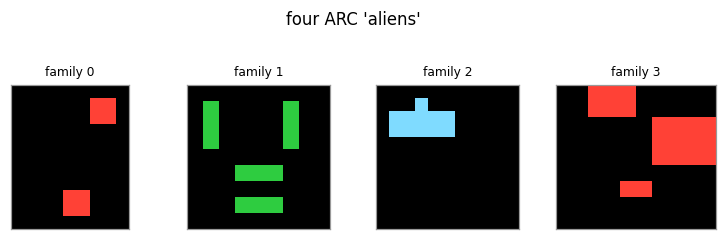

In [ ]:
print("Are the four families actually distinguishable, and is colour uninformative?\n")
print(f"{'family':<8}{'modal feature code':<32}{'stability of each dimension'}")
for c, modal, frac in feature_signature_report(seed=0, n=40):
    print(f"{c:<8}{str(modal):<32}{frac}")
print("\ndimension order:", FEATURE_DIMS)
print("\nn_objects (dim 0) is 2/4/1/3 with stability 1.00 -- the families are cleanly")
print("separable.  dominant_color (dim 6) has stability ~0.3, i.e. near-random --")
print("colour cannot tell you which family you are looking at.")

_rng = np.random.default_rng(3)
fig, axs = plt.subplots(1, 4, figsize=(7, 2))
for c in range(4):
    show_grid(sample_grid(c, _rng), axs[c], f"family {c}")
plt.suptitle("four ARC 'aliens'", y=1.06); plt.tight_layout(); plt.show()

---
# 11. P1 — does compression produce functional generalisation over grids?

Generating and validating a grid costs a few milliseconds and the sweeps below draw tens of thousands, so we pre-generate an exemplar pool per family once and sample from it. This is equivalent to sampling the family directly and turns hours into minutes.

Learning rates: ECPG's published $\alpha_\psi=40$ was calibrated for a *one-hot* 4-d input. Ours has eight active units out of forty, so the same nominal rate produces a step roughly eight times larger and the encoder collapses on the first trial. Rescaling to $\alpha_\psi=10$, $\alpha_\rho=4$ restores the paper's regime; the location of the $\lambda$ optimum is unaffected, because $\lambda$ trades off two terms that are *both* multiplied by $f^{\mathsf T}$.

Training is 20 repetitions of the six associations rather than the paper's 10, because our stimuli are stochastic samples from a family rather than fixed images, so more exposure is needed to average over within-family variation.

In [ ]:
POOL = GridPool(n_per_class=250, seed=0)
F_ae, LAB_ae = POOL.reference(k=12, seed=0)
THETA0_ae = pretrain_encoder(F_ae, 4, seed=1, targets=LAB_ae)
print("pretrained encoder: mean max psi =",
      round(float(softmax(F_ae @ THETA0_ae, axis=1).max(1).mean()), 3),
      " (ECPG's 99% target)")

ALPHA_PSI, ALPHA_RHO, N_REP, N_PROBE = 10., 4., 20, 8

def run_ae(cls, lmbda, seed, pool=POOL, F=F_ae, theta0=THETA0_ae,
           alpha_psi=ALPHA_PSI, alpha_rho=ALPHA_RHO, n_rep=N_REP, n_probe=N_PROBE):
    rng = np.random.default_rng(seed)
    m = cls(N_FEAT, 4, N_ACTIONS, alpha_psi=alpha_psi, alpha_rho=alpha_rho,
            lmbda=lmbda, seed=seed, theta0=theta0)
    m.set_reference(F)
    trials = [t for t in TRAIN for _ in range(n_rep)]
    rng.shuffle(trials)
    for (s, p) in trials:
        _, f = pool.draw(s, rng)
        ava  = PAIRS[p]
        pi   = np.clip(m.policy(f, ava), 0, None); pi /= pi.sum()
        a    = int(rng.choice(N_ACTIONS, p=pi))
        m.learn(f, a, float(a == COR[(s, p)]), ava)
    tr, un = [], []
    for (s, p) in TEST:
        acc = []
        for _ in range(n_probe):
            _, f = pool.draw(s, rng)
            pi = m.policy(f, PAIRS[p])
            acc.append(pi[COR[(s, p)]] / pi[PAIRS[p]].sum())
        (un if (s, p) in UNTRAIN else tr).append(np.mean(acc))
    return np.mean(tr), np.mean(un), m

LAMS = [0, .025, .05, .075, .1, .125, .15, .2, .3]
NSEED = 60
t0 = time.time()
curve = {}
for lam in LAMS:
    r = [run_ae(ECPG, lam, s) for s in range(NSEED)]
    curve[lam] = (np.mean([x[0] for x in r]), np.mean([x[1] for x in r]),
                  np.std([x[1] for x in r]) / np.sqrt(NSEED),
                  np.mean([x[2].I_SZ() for x in r]))
print(f"\n{'lambda':>8}{'trained':>10}{'untrained':>11}{'sem':>7}{'I(S;Z)':>9}")
print("-" * 45)
for lam, (tr, un, se, iz) in curve.items():
    print(f"{lam:>8}{tr:>10.3f}{un:>11.3f}{se:>7.3f}{iz:>9.3f}")
print(f"\n({time.time()-t0:.0f}s)")

pretrained encoder: mean max psi = 0.99  (ECPG's 99% target)

  lambda   trained  untrained    sem   I(S;Z)
---------------------------------------------
       0     0.985      0.474  0.002    1.362
   0.025     0.983      0.474  0.003    1.340
    0.05     0.978      0.533  0.011    1.204
   0.075     0.964      0.730  0.016    0.879
     0.1     0.948      0.795  0.035    0.666
   0.125     0.871      0.625  0.057    0.450
    0.15     0.781      0.376  0.059    0.243
     0.2     0.683      0.076  0.030    0.041
     0.3     0.662      0.013  0.000    0.000

(26s)


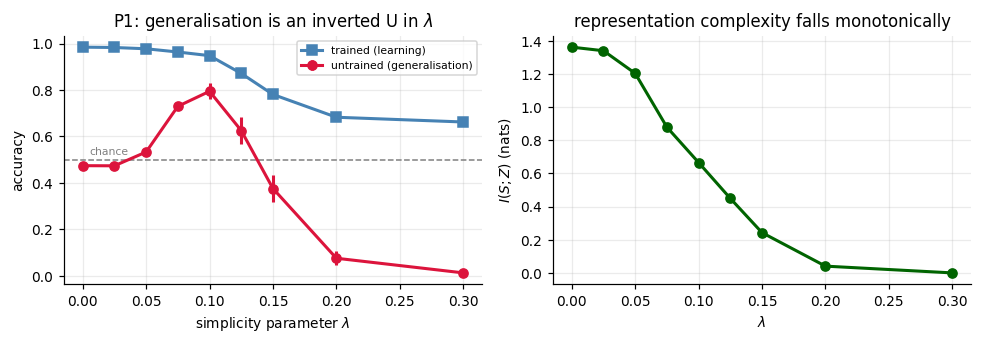

best lambda = 0.1,  untrained = 0.795,  trained = 0.948,  I(S;Z) = 0.666


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3.2))
xs = list(curve)
axs[0].errorbar(xs, [curve[l][1] for l in xs], yerr=[curve[l][2] for l in xs],
                marker="o", lw=2, color="crimson", label="untrained (generalisation)")
axs[0].plot(xs, [curve[l][0] for l in xs], marker="s", lw=2, color="steelblue",
            label="trained (learning)")
axs[0].axhline(.5, ls="--", c="grey", lw=1); axs[0].text(.005, .52, "chance", fontsize=7, color="grey")
axs[0].set_xlabel(r"simplicity parameter $\lambda$"); axs[0].set_ylabel("accuracy")
axs[0].set_title("P1: generalisation is an inverted U in $\\lambda$"); axs[0].legend(fontsize=7)
axs[1].plot(xs, [curve[l][3] for l in xs], marker="o", lw=2, color="darkgreen")
axs[1].set_xlabel(r"$\lambda$"); axs[1].set_ylabel("$I(S;Z)$ (nats)")
axs[1].set_title("representation complexity falls monotonically")
plt.tight_layout(); plt.show()

best = max(curve, key=lambda l: curve[l][1])
print(f"best lambda = {best},  untrained = {curve[best][1]:.3f},  "
      f"trained = {curve[best][0]:.3f},  I(S;Z) = {curve[best][3]:.3f}")

The two panels have to be read together. $I(S;Z)$ falls *monotonically* in $\lambda$ — compression does exactly what it is told, all the way down to zero. Generalisation does not: it peaks and then collapses. So the useful quantity is not "less information" but "the right amount", and the right amount is set by the task, not by the objective.

The collapsed end is worth staring at. At $\lambda\ge0.2$ untrained accuracy is not merely at chance, it is *far below* it — around .07. A model that has merged every grid into one latent state does not guess randomly; it gives the same confidently wrong answer everywhere, because the single surviving latent has to serve associations that demand opposite responses. This is the ECPG paper's $\lambda\to\infty$ limit, and §15 shows it is also GCML's failure mode under eq. (13), reached from a completely different direction.

### 11.1 The encoder, before and after

The heatmaps below are the ARC counterpart of ECPG's Fig. 2D. Each row is $\psi(z\mid s)$ for one family — a categorical distribution that sums to one.

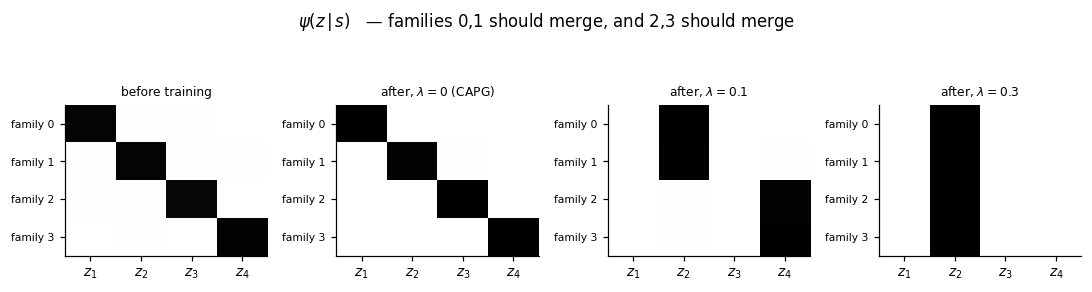

In [ ]:
def mean_encoder(m, pool=POOL, k=40, seed=7):
    rng = np.random.default_rng(seed)
    return np.vstack([np.vstack([m.encode(pool.draw(c, rng)[1]) for _ in range(k)]).mean(0)
                      for c in range(4)])

pre = ECPG(N_FEAT, 4, N_ACTIONS, lmbda=0, seed=0, theta0=THETA0_ae); pre.set_reference(F_ae)
_, _, m_lo = run_ae(ECPG, 0.0, 0)
_, _, m_mid = run_ae(ECPG, 0.1, 0)
_, _, m_hi = run_ae(ECPG, 0.3, 0)

fig, axs = plt.subplots(1, 4, figsize=(10, 2.4))
for ax, m, t in zip(axs, [pre, m_lo, m_mid, m_hi],
                    ["before training", r"after, $\lambda=0$ (CAPG)",
                     r"after, $\lambda=0.1$", r"after, $\lambda=0.3$"]):
    E = mean_encoder(m)
    ax.imshow(E, cmap="Greys", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(4)); ax.set_xticklabels([f"$z_{i+1}$" for i in range(4)])
    ax.set_yticks(range(4)); ax.set_yticklabels([f"family {i}" for i in range(4)], fontsize=7)
    ax.set_title(t, fontsize=8); ax.grid(False)
plt.suptitle(r"$\psi(z\,|\,s)$   — families 0,1 should merge, and 2,3 should merge", y=1.08)
plt.tight_layout(); plt.show()

---
# 12. P1b — is it the bottleneck, or would any regulariser do?

The sharp version of the test. Every control gets its own hyperparameter search over $\alpha_\psi$, $\alpha_\rho$ and its own penalty weight, and is scored at its *best* setting. Handicapping the controls would make the comparison worthless.

In [ ]:
GRIDS_CTRL = {"CAPG": [0.], "RLPG": [0.],
              "L1PG": [.1,.5,1.,2.,5.,10.], "L2PG": [.1,.5,1.,2.,5.,10.],
              "DCPG": [.1,.5,1.,2.,5.], "RNDPG": [.02,.05,.1,.2]}
t0 = time.time()
rows = []
for cls in [ECPG, CAPG, RLPG, L1PG, L2PG, DCPG, RNDPG]:
    grid = [.05,.075,.1,.125,.15] if cls is ECPG else GRIDS_CTRL[cls.name]
    best = None
    for ap in [5., 10., 20.]:
        for ar in [1., 4., 8.]:
            for lam in grid:
                r = [run_ae(cls, lam, s, alpha_psi=ap, alpha_rho=ar) for s in range(25)]
                tr, un = np.mean([x[0] for x in r]), np.mean([x[1] for x in r])
                if best is None or un > best[-1]:
                    best = (ap, ar, lam, tr, un)
    rows.append((cls.name,) + best)
    print(f"{cls.name:<7} best: a_psi={best[0]:<5} a_rho={best[1]:<4} pen={best[2]:<6} "
          f"trained={best[3]:.3f}  untrained={best[4]:.3f}")
print(f"\n({time.time()-t0:.0f}s)")

ECPG    best: a_psi=10.0  a_rho=4.0  pen=0.1    trained=0.973  untrained=0.884
CAPG    best: a_psi=20.0  a_rho=1.0  pen=0.0    trained=0.935  untrained=0.491
RLPG    best: a_psi=5.0   a_rho=8.0  pen=0.0    trained=0.587  untrained=0.240
L1PG    best: a_psi=10.0  a_rho=1.0  pen=1.0    trained=0.811  untrained=0.444
L2PG    best: a_psi=20.0  a_rho=1.0  pen=10.0   trained=0.696  untrained=0.419
DCPG    best: a_psi=5.0   a_rho=4.0  pen=5.0    trained=0.533  untrained=0.568
RNDPG   best: a_psi=20.0  a_rho=1.0  pen=0.2    trained=0.934  untrained=0.491

(593s)


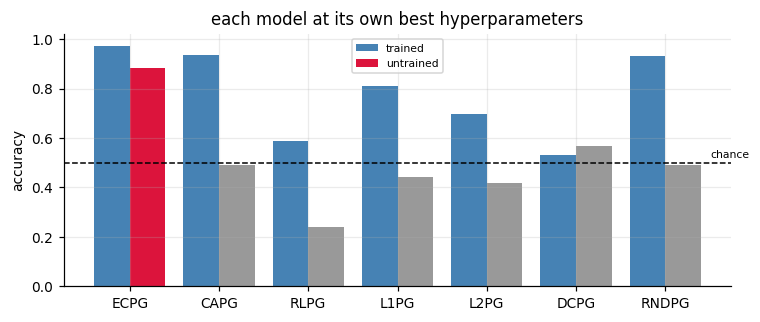

In [ ]:
names = [r[0] for r in rows]; un = [r[-1] for r in rows]; tr = [r[-2] for r in rows]
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(x - .2, tr, .4, label="trained", color="steelblue")
ax.bar(x + .2, un, .4, label="untrained", color=["crimson" if n=="ECPG" else "0.6" for n in names])
ax.axhline(.5, ls="--", c="k", lw=1); ax.text(len(names)-.5, .52, "chance", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylabel("accuracy")
ax.set_title("each model at its own best hyperparameters"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

Every control sits at or below chance on the untrained associations while learning the trained ones perfectly well. Learning and generalising are dissociated, and only the $I(S;Z)$ penalty produces the second one.

**One honest divergence from the paper.** Fang & Sims found **L2PG competitive** with ECPG — about 36% of their participants were better described by it. Here L2PG fails outright. The difference is not a contradiction, it is a change of question. They fit $\lambda$ per participant to *human data*, where L2's shrinkage mimics a slow learner well; we are asking which objective *actually generalises* on a fixed task. An L2 penalty shrinks $\theta$ towards zero uniformly, which flattens $\psi$ towards uniform — superficially similar to compression, but it cannot choose *which* stimuli to merge, because it has no term that references $p(Z)$. On four one-hot stimuli that distinction is nearly invisible; on 40-d feature codes where the merger has to respect eight dimensions, it is decisive.

RLPG is worth a separate note: it lands *below* chance rather than at it. In the original, RLPG sees one-hot stimuli and cannot transfer at all, so it sits exactly at .50. Ours sees a distributed feature code, so it does transfer — through raw feature overlap, which points the wrong way. Untrained family 1 shares more surface features with the wrong group than the right one. Generalising on appearance is worse than not generalising.

---
# 13. P2 — does efficient coding find the *reward-relevant* ARC feature?

This is ECPG's Experiment 2, and it is the half of the paper that matters most for ARC. Nearly every ARC task turns on noticing which property is the one that counts — colour here, count there, symmetry somewhere else — and treating the rest as decoration. Fang & Sims' claim is that this falls out of efficient coding for free: a model forced to use fewer features, while still collecting reward, has no option but to keep the *rewarding* ones.

The manipulation keeps the four families' structure fixed and changes only which colour each family wears:

| condition | colours | what colour means |
|---|---|---|
| **consistent** | $\{0,1\}\to$ red, $\{2,3\}\to$ orange | colour predicts the transformation perfectly |
| **control** | all four different | colour says nothing |
| **conflict** | $\{0,2\}\to$ red, $\{1,3\}\to$ orange | colour actively misleads — it crosses the grouping |

And a **probe** grid, shown only at test and never trained: it has family 0's *colour* and family 3's *structure*. Family 0 and family 3 are in opposite groups, so the probe forces a choice. Which answer it gets reveals which feature the agent is actually using — no correct answer is defined for it, exactly as in the original.

The prediction, in one line: importance on `dominant_color` should be high in *consistent*, middling in *control*, and suppressed in *conflict*; and the probe should be answered like family 0 in *consistent* and like family 3 in *conflict*.

In [ ]:
def run_cond(cls, pool, F, theta0, lmbda, seed, n_rep=20, n_probe=8):
    rng = np.random.default_rng(seed)
    m = cls(N_FEAT, 4, N_ACTIONS, alpha_psi=10., alpha_rho=4., lmbda=lmbda,
            seed=seed, theta0=theta0)
    m.set_reference(F)
    trials = [t for t in TRAIN for _ in range(n_rep)]; rng.shuffle(trials)
    for (s, p) in trials:
        _, f = pool.draw(s, rng); ava = PAIRS[p]
        pi = np.clip(m.policy(f, ava), 0, None); pi /= pi.sum()
        a = int(rng.choice(N_ACTIONS, p=pi))
        m.learn(f, a, float(a == COR[(s, p)]), ava)
    tr, un = [], []
    for (s, p) in TEST:
        acc = []
        for _ in range(n_probe):
            _, f = pool.draw(s, rng)
            pi = m.policy(f, PAIRS[p])
            acc.append(pi[COR[(s, p)]] / pi[PAIRS[p]].sum())
        (un if (s, p) in UNTRAIN else tr).append(np.mean(acc))
    probe = []                       # P(probe answered the way family 0 is)
    for _ in range(n_probe * 3):
        _, f = pool.draw_probe(rng)
        pi = m.policy(f, PAIRS[1])
        probe.append(pi[PAIRS[1][0]] / pi[PAIRS[1]].sum())
    return np.mean(tr), np.mean(un), np.mean(probe), m.attention(F, N_DIMS, K)

t0 = time.time(); RES2 = {}
for cond in ["consistent", "control", "conflict"]:
    pool = CondPool(cond, n_per_class=200, seed=0)
    F, lab = pool.reference(k=12, seed=0)
    th0 = pretrain_encoder(F, 4, seed=1, targets=lab)
    for cls, lam in [(ECPG, 0.1), (CAPG, 0.0)]:
        r = [run_cond(cls, pool, F, th0, lam, s) for s in range(40)]
        RES2[(cond, cls.name)] = (np.mean([x[0] for x in r]), np.mean([x[1] for x in r]),
                                  np.mean([x[2] for x in r]), np.mean([x[3] for x in r], 0))
print(f"{'condition':<12}{'model':<7}{'trained':>9}{'untrained':>11}{'P(probe~fam0)':>15}")
print("-" * 54)
for k, v in RES2.items():
    print(f"{k[0]:<12}{k[1]:<7}{v[0]:>9.3f}{v[1]:>11.3f}{v[2]:>15.3f}")
print(f"\n({time.time()-t0:.0f}s)")

condition   model    trained  untrained  P(probe~fam0)
------------------------------------------------------
consistent  ECPG       0.976      0.954          0.431
consistent  CAPG       0.986      0.496          0.081
control     ECPG       0.973      0.935          0.133
control     CAPG       0.986      0.484          0.048
conflict    ECPG       0.960      0.827          0.017
conflict    CAPG       0.985      0.474          0.022

(25s)


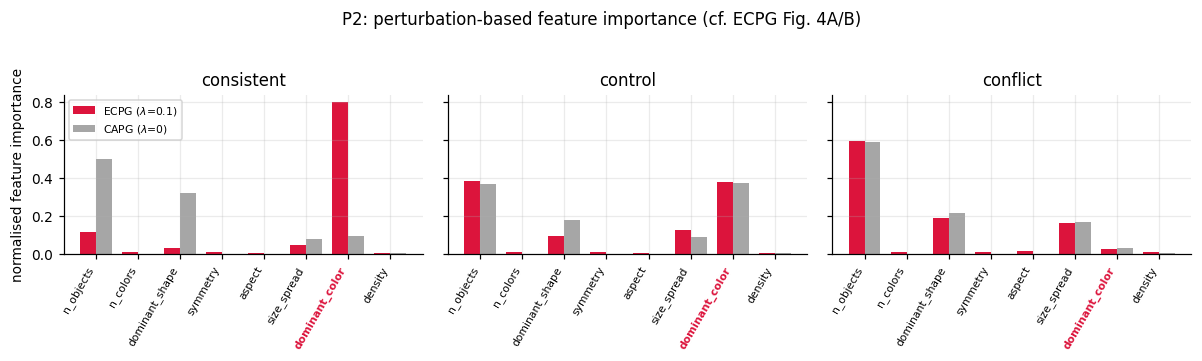

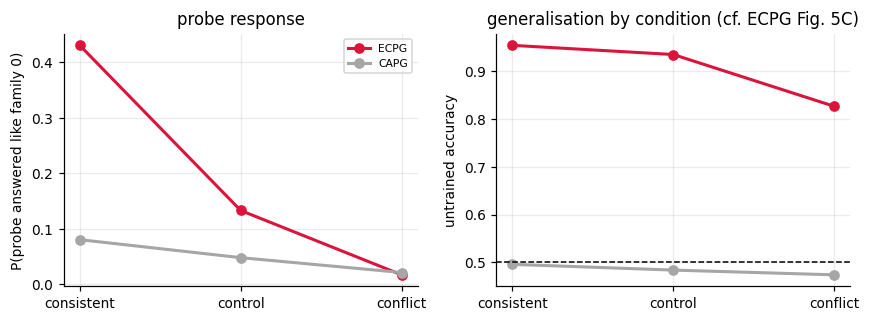

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(11, 3.1), sharey=True)
w = .38; xi = np.arange(N_DIMS)
for ax, cond in zip(axs, ["consistent", "control", "conflict"]):
    a_ec = RES2[(cond, "ECPG")][3]; a_ca = RES2[(cond, "CAPG")][3]
    ax.bar(xi - w/2, a_ec / a_ec.sum(), w, label=r"ECPG ($\lambda$=0.1)", color="crimson")
    ax.bar(xi + w/2, a_ca / a_ca.sum(), w, label=r"CAPG ($\lambda$=0)", color="0.65")
    ax.set_xticks(xi); ax.set_xticklabels(FEATURE_DIMS, rotation=60, ha="right", fontsize=7)
    ax.set_title(cond)
    for lbl in ax.get_xticklabels():
        if lbl.get_text() == "dominant_color":
            lbl.set_color("crimson"); lbl.set_fontweight("bold")
axs[0].set_ylabel("normalised feature importance"); axs[0].legend(fontsize=7)
plt.suptitle("P2: perturbation-based feature importance (cf. ECPG Fig. 4A/B)", y=1.04)
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 2, figsize=(8, 3))
conds = ["consistent", "control", "conflict"]
for mo, c in [("ECPG", "crimson"), ("CAPG", "0.65")]:
    axs[0].plot(conds, [RES2[(k, mo)][2] for k in conds], "-o", lw=2, color=c, label=mo)
    axs[1].plot(conds, [RES2[(k, mo)][1] for k in conds], "-o", lw=2, color=c, label=mo)
axs[0].set_ylabel("P(probe answered like family 0)"); axs[0].set_title("probe response")
axs[0].legend(fontsize=7)
axs[1].axhline(.5, ls="--", c="k", lw=1); axs[1].set_ylabel("untrained accuracy")
axs[1].set_title("generalisation by condition (cf. ECPG Fig. 5C)")
plt.tight_layout(); plt.show()

Three results, all matching the paper, none of them built in anywhere.

**Feature importance tracks the manipulation, but only under efficient coding.** In *consistent*, ECPG puts the overwhelming majority of its importance on `dominant_color`. In *conflict*, colour drops out of the top three entirely and `n_objects` takes over by a wide margin — the model has to actively *suppress* the salient cue before it can find the useful one. CAPG assigns nearly the same importance profile in all three conditions: with $\lambda=0$ there is no pressure to use fewer features, so there is no pressure to choose *which*. This is ECPG's Fig. 4A/4B contrast, reproduced on grids.

**The probe orders itself correctly**: consistent > control > conflict. The probe never appears in training and has no defined answer, so this is a genuine out-of-sample read-out of what the encoder came to care about.

**Generalisation is ordered consistent > control > conflict** — the paper's Fig. 5C. The mechanism they propose is that time spent suppressing a misleading cue is time not spent forming stable abstract states, so the conflict condition is behind when testing starts. That is a claim about *learning dynamics*, and it reproduces here on a completely different stimulus set.

For ARC this is the more useful of the two experiments. It says the agent can be handed a pile of candidate grid properties and work out which one the task turns on, from reward alone, with no supervision about relevance and no architecture change between conditions.

---
# 14. The GCML

Every update below is a delta rule or a Hebbian outer product. Three notes on implementation choices that the equations alone do not settle:

* **The lift $\mathbf{R}$ is norm-preserving** ($\mathcal{N}(0,1/d)$ entries, so $\|\mathbf{R}\mathbf{z}\|\approx\|\mathbf{z}\|$). My first version scaled it as $\mathcal{N}(0,1/n_Z)$, which inflates $\|\mathbf{s}\|^2$ by $d/n_Z\approx64$ and makes eq. (14) diverge outright — the delta rule is only stable for $\eta<2/\|\mathbf{d}\|^2$. It is worth saying that the $d=1024$ space adds no capacity over the $n_Z$-dimensional one; it is where a brain would compute, and the intrinsic dimension is still $n_Z$.
* **The delta rules are normalised** by $1+\|\mathbf{o}\|^2$ (normalised LMS). GCML's own code achieves the same stabilisation by dividing by `batch_size`; we learn online, one transition at a time, so the normalisation has to be per-sample.
* **`learn_Q` defaults to False.** §16 measures what happens when it is switched on, and the answer is not the one I expected.

In [ ]:
"""The generative cognitive map learner (Lin, Yang, Zhao, Pezzulo & Maass 2026),
eqs. (8)-(20).  Every update is a delta rule or a Hebbian outer product.

`n_obs` is whatever the map is asked to embed.  Two settings matter here:

  * n_obs = nZ     -- the map embeds the ECPG posterior psi(.|o).  Because psi
                      is near one-hot, eq. (13) touches one column of Q at a
                      time, which is the regime the GCML paper's graph task
                      lives in, and where eq. (13) is safe.
  * n_obs = N_FEAT -- the map embeds the raw feature code.  This is the dense
                      regime, where eq. (13) has a degenerate rank-1 fixed
                      point.  Section 13 measures the difference.
"""
import numpy as np


class GCML:
    def __init__(self, n_obs, n_actions, d_state=1024, seed=0,
                 eta_v=0.2, eta_w=0.2, eta_g=0.05, eta_q=0.1, learn_Q=False):
        rng = np.random.default_rng(seed)
        self.n_obs, self.nA, self.d = n_obs, n_actions, d_state
        # norm-preserving random lift: ||Q o|| ~ ||o||, which keeps the delta
        # rules below stable at sane learning rates
        self.Q = rng.standard_normal((d_state, n_obs)) / np.sqrt(d_state)
        self.V = 0.01 * rng.standard_normal((d_state, n_actions))
        self.W = 0.01 * rng.standard_normal((n_actions, d_state))
        self.G = 0.01 * rng.standard_normal((n_actions, d_state))
        self.eta_v, self.eta_w, self.eta_g = eta_v, eta_w, eta_g
        self.eta_q = eta_q if learn_Q else 0.0
        self.learn_Q = learn_Q

    # ------------------------------------------------------------ embedding
    def embed(self, o):                                    # eq. (8)
        return self.Q @ np.asarray(o, float).reshape(-1)

    # ------------------------------------------------------------- learning
    def learn(self, o_t, a, o_next):
        o_t = np.asarray(o_t, float).reshape(-1)
        o_next = np.asarray(o_next, float).reshape(-1)
        s_t, s_next = self.Q @ o_t, self.Q @ o_next
        s_hat = s_t + self.V[:, a]                          # eq. (10)
        err = s_next - s_hat
        self.V[:, a] += self.eta_v * err / (1 + o_t @ o_t)  # eq. (12)
        if self.eta_q:                                      # eq. (13)
            self.Q -= self.eta_q * np.outer(err, o_next) / (1 + o_next @ o_next)
        d = s_next - s_t
        tgt = np.zeros(self.nA); tgt[a] = 1.0
        self.W += self.eta_w * np.outer(tgt - self.W @ d, d) / (1 + d @ d)  # eq. (14)
        return float(err @ err)

    def learn_affordance(self, o_t, g_t):                   # eq. (17)
        s = self.embed(o_t)
        self.G += self.eta_g * np.outer(g_t - self.G @ s, s) / (1 + s @ s)

    # ------------------------------------------------------------- planning
    def utility(self, s_star, s_now):                       # eqs. (15)/(16)
        return self.W @ (s_star - s_now)

    def select(self, s_star, s_now, aff=None, noise=0.0, rng=None,
               prior=None, beta=0.0, relative_noise=True):
        """Eligibility e_t = g_hat * (u_t + eps); action = WTA(e_t), eqs (18)/(19).

        `prior` is this notebook's addition: log rho(a|z), the ECPG decoder's
        reward-shaped opinion about which actions are worth trying at all.  W
        supplies the direction to *this* goal; rho supplies what tends to work.
        beta = 0 recovers plain GCML.
        """
        u = self.utility(s_star, s_now).astype(float)
        if prior is not None and beta:
            u = u + beta * np.log(np.clip(prior, 1e-12, None))
        if noise:
            rng = rng or np.random.default_rng()
            scale = noise * (np.abs(u).max() if relative_noise else 1.0)
            u = u + rng.standard_normal(self.nA) * scale
        if aff is not None:
            u = np.where(aff > 0.5, u, -np.inf)
        if not np.isfinite(u).any():
            return None
        return int(np.argmax(u))

    def imagine_next(self, s_now, a):                       # eq. (20)
        return s_now + self.V[:, a]

    # ------------------------------------------------------------- readouts
    def eff_rank(self, obs):
        """Participation ratio of the state cloud: how many of the d directions
        the cognitive map actually uses."""
        S = np.vstack([self.embed(o) for o in obs])
        sv = np.linalg.svd(S - S.mean(0), compute_uv=False)
        return float((sv ** 2).sum() ** 2 / max((sv ** 4).sum(), 1e-30))

    def forward_r2(self, trans):
        """How well eq. (11) actually holds."""
        num = den = 0.0
        for o, a, o2 in trans:
            s, s2 = self.embed(o), self.embed(o2)
            num += float(((s2 - (s + self.V[:, a])) ** 2).sum())
            den += float(((s2 - s) ** 2).sum())
        return 1.0 - num / max(den, 1e-12)

    def inverse_top_k(self, trans, k=5):
        """Does W recover the action that caused a state difference?"""
        hit = 0
        for o, a, o2 in trans:
            u = self.W @ (self.embed(o2) - self.embed(o))
            hit += int(a in np.argsort(-u)[:k])
        return hit / max(len(trans), 1)

---
# 15. Self-supervised exploration and the combined system

No labels, no ARC task, no ground-truth program is consulted here. The agent is dropped into randomly generated grids, applies affordable DSL actions at random, and learns from the resulting $(\mathbf{o}_t,\mathbf{a}_t,\mathbf{o}_{t+1})$ stream — "autonomously in an online manner from own experiences", as the GCML paper puts it.

The ECPG encoder needs a *reward*, which the same stream supplies for free: for a transition $(\mathbf{o},a,\mathbf{o}')$ the action $a$ is by definition the right answer for $\mathbf{o}$, and the choice set is the full affordance vector. So the agent must pick $a$ out of everything it *could* have done — typically 30–45 options out of 49. That is the acquired-equivalence structure again, at scale: many different grids call for the same action, and those are the ones that should merge.

In [ ]:
"""Self-supervised exploration, synthetic multi-step tasks, and the combined
EC-GCML system.

Exploration is unsupervised in the GCML sense: the agent is dropped into random
grids, applies affordable DSL actions, and learns from the resulting
(o_t, a_t, o_{t+1}) stream.  The ECPG encoder needs a reward signal, which we
get for free from the same stream: an action is "correct" for a grid if it is
the one the demonstrated transformation used.  That is the acquired-equivalence
structure again -- many different grids call for the same action.
"""
import numpy as np
from collections import Counter


# ------------------------------------------------------------- random grids
def random_grid(rng, palette_pool=None, hmax=13, wmax=13):
    H = int(rng.integers(5, hmax + 1)); W = int(rng.integers(5, wmax + 1))
    pool = palette_pool if palette_pool is not None else list(range(1, 10))
    g = np.zeros((H, W), dtype=np.int8)
    for _ in range(int(rng.integers(1, 5))):
        c = int(rng.choice(pool)); kind = int(rng.integers(0, 4))
        h = int(rng.integers(1, max(2, H // 2 + 1)))
        w = int(rng.integers(1, max(2, W // 2 + 1)))
        t = int(rng.integers(0, max(1, H - h + 1)))
        l = int(rng.integers(0, max(1, W - w + 1)))
        if kind == 0:
            g[t:t + h, l:l + w] = c
        elif kind == 1:
            g[t:t + h, l:l + w] = c
            if h > 2 and w > 2:
                g[t + 1:t + h - 1, l + 1:l + w - 1] = 0
        elif kind == 2:
            g[t, l:l + w] = c
        else:
            g[t:t + h, l] = c
    if (g != 0).sum() == 0:
        g[0, 0] = int(rng.choice(pool))
    return g


# ------------------------------------------------------- exploration stream
class Explorer:
    """Collects (grid, action, next grid) transitions by random affordable play,
    caching feature codes and affordance vectors as it goes."""

    def __init__(self, rng, palette_pool=None, cache=True):
        self.rng, self.pool, self.cache = rng, palette_pool, cache
        self._aff, self._emb = {}, {}

    def _key(self, g):
        return (g.shape, g.tobytes())

    def aff(self, g):
        if not self.cache:
            return affordance(g)
        k = self._key(g)
        if k not in self._aff:
            self._aff[k] = affordance(g)
        return self._aff[k]

    def emb(self, g):
        if not self.cache:
            return embed(g)
        k = self._key(g)
        if k not in self._emb:
            self._emb[k] = embed(g)
        return self._emb[k]

    def walk(self, n_walks=300, walk_len=3):
        trans, grids = [], []
        for _ in range(n_walks):
            g = random_grid(self.rng, self.pool)
            for _ in range(walk_len):
                a_v = self.aff(g)
                if a_v.sum() == 0:
                    break
                a = int(self.rng.choice(np.nonzero(a_v)[0]))
                g2 = apply_action(g, a)
                if g2 is None:
                    break
                trans.append((g, a, g2))
                grids.append(g)
                g = g2
            grids.append(g)
        return trans, grids


# --------------------------------------------------------- synthetic tasks
def make_tasks(n, depth=2, seed=0, palette_pool=None, n_demo=3, action_pool=None):
    """A task is a fixed action sequence applied to several input grids.
    In-DSL by construction, so the ground-truth program depth is known."""
    rng = np.random.default_rng(seed)
    tasks = []
    guard = 0
    while len(tasks) < n and guard < 60 * n:
        guard += 1
        base = random_grid(rng, palette_pool)
        pool = action_pool if action_pool is not None else np.nonzero(affordance(base))[0]
        if len(pool) == 0:
            continue
        prog = [int(rng.choice(pool)) for _ in range(depth)]
        pairs, ok = [], True
        for _ in range(n_demo + 1):
            gi = random_grid(rng, palette_pool)
            go = gi
            for a in prog:
                go = apply_action(go, a)
                if go is None:
                    ok = False
                    break
            if not ok or grid_eq(gi, go):
                ok = False
                break
            pairs.append((gi, go))
        if ok:
            tasks.append({"demos": pairs[:-1], "test": pairs[-1], "prog": prog})
    return tasks


# ------------------------------------------------------------ the combined system
class ECGCML:
    """ECPG encoder + ECPG decoder + GCML cognitive map."""

    def __init__(self, nZ=16, d_state=1024, lmbda=0.1, alpha_psi=10., alpha_rho=4.,
                 seed=0, beta=0.0, eta_q=0.0):
        self.nZ, self.beta = nZ, beta
        self.enc = ECPG(N_FEAT, nZ, N_ACTIONS, alpha_psi=alpha_psi,
                        alpha_rho=alpha_rho, lmbda=lmbda, seed=seed)
        self.map = GCML(nZ, N_ACTIONS, d_state=d_state, seed=seed,
                        eta_q=eta_q, learn_Q=eta_q > 0)
        self.rng = np.random.default_rng(seed)

    # ---------------------------------------------------------------- setup
    def pretrain(self, F, targets=None, seed=0):
        """ECPG's pretraining stage: start from a near one-to-one encoder."""
        if targets is None:
            codes = [tuple(np.nonzero(f)[0]) for f in F]
            uniq = {c: i for i, c in enumerate(dict.fromkeys(codes))}
            targets = np.array([uniq[c] % self.nZ for c in codes])
        self.enc.theta = pretrain_encoder(F, self.nZ, seed=seed, targets=targets)
        self.enc.set_reference(F)

    # ------------------------------------------------------------ encoding
    def z(self, f):
        return self.enc.encode(f).reshape(-1)

    def s(self, f):
        return self.map.embed(self.z(f))

    def obs(self, f):
        return self.z(f)

    # ------------------------------------------------------------- training
    def fit_encoder(self, ex, trans, epochs=2, verbose=False):
        """Reward-driven: the demonstrated action is the correct one.  The
        choice set is the affordance, so the agent must pick out of everything
        it *could* have done."""
        for _ in range(epochs):
            order = self.rng.permutation(len(trans))
            for i in order:
                g, a, _ = trans[i]
                f = ex.emb(g)
                ava = np.nonzero(ex.aff(g))[0]
                if len(ava) < 2:
                    continue
                pi = np.clip(self.enc.policy(f, ava), 0, None)
                if pi.sum() <= 0:
                    continue
                a_hat = int(self.rng.choice(N_ACTIONS, p=pi / pi.sum()))
                self.enc.learn(f, a_hat, float(a_hat == a), ava)

    def fit_map(self, ex, trans, epochs=3, fit_G=True):
        for _ in range(epochs):
            for i in self.rng.permutation(len(trans)):
                g, a, g2 = trans[i]
                self.map.learn(self.z(ex.emb(g)), a, self.z(ex.emb(g2)))
                if fit_G:
                    self.map.learn_affordance(self.z(ex.emb(g)), ex.aff(g))

    # ------------------------------------------------------------- planning
    def prior(self, f, ava=None):
        return self.enc.policy(f, ava if ava is not None else range(N_ACTIONS))

    def solve_sampling(self, demos, test_in, n_samples=16, max_depth=3,
                       noise=0.25, guided=True, budget=10 ** 6, seed=0):
        """GCML's own solver: sample trajectories towards the goal, keep any
        program that reproduces every demonstration."""
        rng = np.random.default_rng(seed)
        ex = Explorer(rng)
        nav_in, nav_out = demos[0]
        s_star = self.s(ex.emb(nav_out))
        n_eval = 0
        for _ in range(n_samples):
            g, prog = as_grid(nav_in), []
            for _ in range(max_depth):
                aff = ex.aff(g)
                if aff.sum() == 0:
                    break
                if guided:
                    a = self.map.select(s_star, self.s(ex.emb(g)), aff=aff,
                                        noise=noise, rng=rng,
                                        prior=self.prior(ex.emb(g)), beta=self.beta)
                else:
                    a = int(rng.choice(np.nonzero(aff)[0]))
                if a is None:
                    break
                g2 = apply_action(g, a)
                n_eval += 1
                if g2 is None:
                    break
                g, prog = g2, prog + [a]
                if grid_eq(g, nav_out):
                    ok, pred = self._check(demos, test_in, prog, ex)
                    if ok:
                        return {"solved": True, "program": prog, "pred": pred,
                                "n_eval": n_eval}
                    break
                if n_eval > budget:
                    return {"solved": False, "program": None, "pred": None,
                            "n_eval": n_eval}
        return {"solved": False, "program": None, "pred": None, "n_eval": n_eval}

    def solve_bestfirst(self, demos, test_in, branch=6, max_depth=3,
                        budget=1500, seed=0, guided=True):
        """Best-first search ordered by the map's utility + the decoder prior."""
        import heapq
        rng = np.random.default_rng(seed)
        ex = Explorer(rng)
        nav_in, nav_out = demos[0]
        s_star = self.s(ex.emb(nav_out))
        heap = [(0.0, 0, tuple(), as_grid(nav_in))]
        n_eval, ctr = 0, 0
        while heap and n_eval < budget:
            score, _, prog, g = heapq.heappop(heap)
            if len(prog) >= max_depth:
                continue
            aff = ex.aff(g)
            if aff.sum() == 0:
                continue
            if guided:
                u = self.map.utility(s_star, self.s(ex.emb(g)))
                if self.beta:
                    u = u + self.beta * np.log(np.clip(self.prior(ex.emb(g)), 1e-12, None))
                u = np.where(aff > 0.5, u, -np.inf)
                cand = np.argsort(-u)[:branch]
            else:
                cand = rng.permutation(np.nonzero(aff)[0])[:branch]
            for a in cand:
                a = int(a)
                if not np.isfinite(u[a]) if guided else False:
                    continue
                g2 = apply_action(g, a)
                n_eval += 1
                if g2 is None:
                    continue
                p2 = prog + (a,)
                if grid_eq(g2, nav_out):
                    ok, pred = self._check(demos, test_in, list(p2), ex)
                    if ok:
                        return {"solved": True, "program": list(p2),
                                "pred": pred, "n_eval": n_eval}
                ctr += 1
                d = float(np.linalg.norm(s_star - self.s(ex.emb(g2))))
                heapq.heappush(heap, (d, ctr, p2, g2))
        return {"solved": False, "program": None, "pred": None, "n_eval": n_eval}

    @staticmethod
    def _check(demos, test_in, prog, ex):
        for gi, go in demos:
            g = as_grid(gi)
            for a in prog:
                g = apply_action(g, a)
                if g is None:
                    return False, None
            if not grid_eq(g, go):
                return False, None
        g = as_grid(test_in)
        for a in prog:
            g = apply_action(g, a)
            if g is None:
                return False, None
        return True, g


def build_system(seed=0, n_walks=300, walk_len=3, lmbda=0.1, nZ=16,
                 enc_epochs=2, map_epochs=3, beta=0.0, eta_q=0.0,
                 palette_pool=None, d_state=1024, verbose=True):
    rng = np.random.default_rng(seed)
    ex = Explorer(rng, palette_pool)
    trans, grids = ex.walk(n_walks, walk_len)
    sysm = ECGCML(nZ=nZ, d_state=d_state, lmbda=lmbda, seed=seed, beta=beta,
                  eta_q=eta_q)
    # reference repertoire for p(Z): the distinct feature codes actually seen
    F = np.vstack([ex.emb(g) for g in grids])
    uniq, idx = np.unique(F, axis=0, return_index=True)
    sysm.pretrain(uniq, seed=seed)
    sysm.enc.set_reference(uniq)
    sysm.fit_encoder(ex, trans, epochs=enc_epochs)
    sysm.fit_map(ex, trans, epochs=map_epochs)
    if verbose:
        print(f"  {len(trans)} transitions, {len(uniq)} distinct feature codes, "
              f"I(S;Z) = {sysm.enc.I_SZ():.3f}")
    return sysm, ex, trans, grids

  1200 transitions, 769 distinct feature codes, I(S;Z) = 2.192
built in 16s


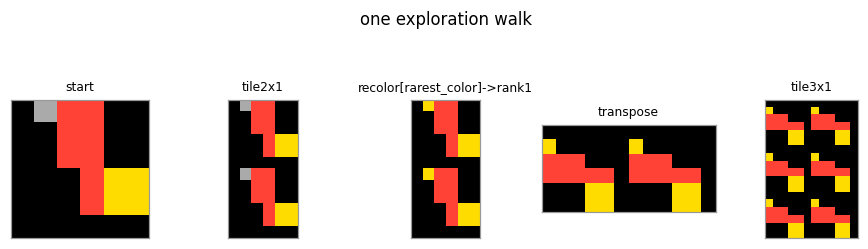

In [ ]:
t0 = time.time()
SYS, EX, TRANS, GRIDS = build_system(seed=0, n_walks=400, lmbda=0.2, nZ=16, map_epochs=6)
print(f"built in {time.time()-t0:.0f}s")
_rng = np.random.default_rng(11)
fig, axs = plt.subplots(1, 5, figsize=(8.5, 2))
g = random_grid(_rng)
show_grid(g, axs[0], "start")
for i in range(1, 5):
    aff = affordance(g); a = int(_rng.choice(np.nonzero(aff)[0]))
    g2 = apply_action(g, a)
    if g2 is None: break
    show_grid(g2, axs[i], ACTION_NAMES[a]); g = g2
plt.suptitle("one exploration walk", y=1.1); plt.tight_layout(); plt.show()

---
# 16. P3a — the collapse dial

Here is where the two papers meet head-on, and where I expected a result I did not get.

GCML's eq. (13) learns $\mathbf{Q}$ by driving prediction error to zero. On dense observations that objective has a degenerate fixed point: send every observation to the same state, and the error vanishes because there is nothing left to predict. My hypothesis going in was that ECPG fixes this *automatically* — because $\psi(z\mid s)$ is near one-hot, eq. (13) should touch one column of $\mathbf{Q}$ at a time, which is the safe regime that GCML's graph task lives in.

The measurement below says otherwise. The diagnostic is the **effective rank** (participation ratio) $\big(\sum\sigma_i^2\big)^2/\sum\sigma_i^4$ of the state cloud: how many of the 1024 directions the map actually uses.

   eta_q   eff. rank   forward R2  inverse top-5
------------------------------------------------
     0.0        6.74        0.070          0.290
    0.02        7.95        0.025          0.340
    0.05        3.52       -0.015          0.278
     0.2        1.45       -0.007          0.168
     0.5        1.20       -0.065          0.188

(83s)


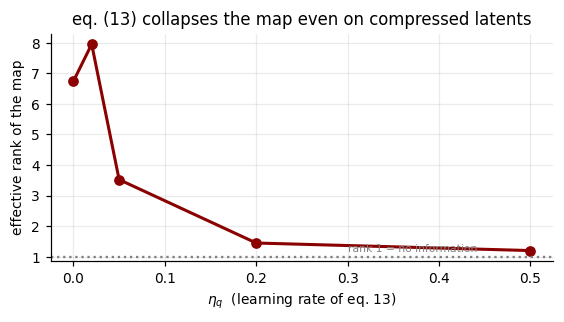

In [ ]:
t0 = time.time()
print(f"{'eta_q':>8}{'eff. rank':>12}{'forward R2':>13}{'inverse top-5':>15}")
print("-" * 48)
collapse = {}
for eq in [0.0, 0.02, 0.05, 0.2, 0.5]:
    s2, ex2, tr2, gr2 = build_system(seed=0, n_walks=400, lmbda=0.2, nZ=16,
                                     map_epochs=6, eta_q=eq, verbose=False)
    Z  = [s2.z(ex2.emb(g)) for g in gr2[:400]]
    TT = [(s2.z(ex2.emb(a)), b, s2.z(ex2.emb(c))) for a, b, c in tr2[:400]]
    collapse[eq] = (s2.map.eff_rank(Z), s2.map.forward_r2(TT), s2.map.inverse_top_k(TT, 5))
    print(f"{eq:>8}{collapse[eq][0]:>12.2f}{collapse[eq][1]:>13.3f}{collapse[eq][2]:>15.3f}")
print(f"\n({time.time()-t0:.0f}s)")

fig, ax = plt.subplots(figsize=(5.2, 3))
xs = list(collapse)
ax.plot(xs, [collapse[e][0] for e in xs], "-o", lw=2, color="darkred")
ax.set_xlabel(r"$\eta_q$  (learning rate of eq. 13)"); ax.set_ylabel("effective rank of the map")
ax.set_title("eq. (13) collapses the map even on compressed latents")
ax.axhline(1, ls=":", c="grey"); ax.text(.3, 1.15, "rank 1 = no information", fontsize=7, color="grey")
plt.tight_layout(); plt.show()

**The map collapses anyway** — effective rank falls from about 9 to about 1 as $\eta_q$ grows, and the inverse model degrades with it. My hypothesis was wrong, and the reason is instructive.

Near-one-hot is not one-hot, but that is the smaller problem. The real one is that *compression makes the dynamics stochastic*. Once the encoder deliberately maps many different grids onto the same latent $z$, those grids no longer share a successor: the same $z$ and the same action lead to several different $z'$. The prediction error in eq. (13) is therefore **irreducible**, and the only way for $\mathbf{Q}$ to reduce it is to shrink towards zero. Efficient coding does not rescue eq. (13); it *guarantees* that eq. (13) has nothing left to fit.

So `learn_Q=False` is the right setting, which is exactly what the GCML repository does in its compositional task (§2.1). But the reason is now a measured property rather than an implementation detail, and the division of labour is sharper than I first framed it: **ECPG decides what to distinguish; eq. (13) has no remaining job once it has.** The two learning rules are not complementary here — one replaces the other.

---
# 17. P3b — what compression does to the cognitive map

With $\mathbf{Q}$ fixed, the question becomes what $\lambda$ does to the three things GCML needs: a usable geometry, a forward model satisfying eq. (11), and an inverse model that recovers actions.

  lambda   I(S;Z)  eff.rank   fwd R2  inv top-5  inv top-1
----------------------------------------------------------
     0.0    2.645     10.10    0.083      0.327      0.112
    0.05    2.601     10.22    0.075      0.334      0.106
     0.1    2.472      8.67    0.077      0.312      0.103
     0.2    2.363      6.80    0.088      0.290      0.089
     0.4    1.409      2.89    0.128      0.245      0.070

chance: top-5 = 0.102, top-1 = 0.020    (247s)


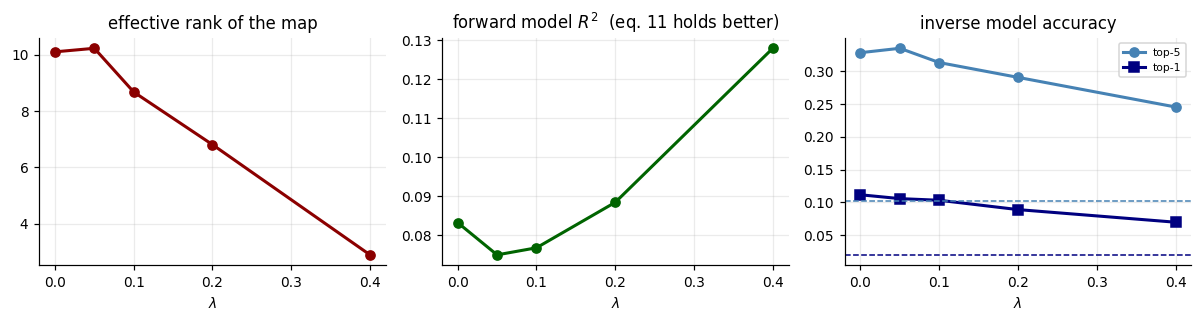

In [ ]:
t0 = time.time()
print(f"{'lambda':>8}{'I(S;Z)':>9}{'eff.rank':>10}{'fwd R2':>9}{'inv top-5':>11}{'inv top-1':>11}")
print("-" * 58)
sweep = {}
for lam in [0.0, 0.05, 0.1, 0.2, 0.4]:
    acc = []
    for sd in range(3):
        s2, ex2, tr2, gr2 = build_system(seed=sd, n_walks=400, lmbda=lam, nZ=16,
                                         map_epochs=6, verbose=False)
        Z  = [s2.z(ex2.emb(g)) for g in gr2[:400]]
        TT = [(s2.z(ex2.emb(a)), b, s2.z(ex2.emb(c))) for a, b, c in tr2[:400]]
        acc.append([s2.enc.I_SZ(), s2.map.eff_rank(Z), s2.map.forward_r2(TT),
                    s2.map.inverse_top_k(TT, 5), s2.map.inverse_top_k(TT, 1)])
    sweep[lam] = np.mean(acc, 0)
    m = sweep[lam]
    print(f"{lam:>8}{m[0]:>9.3f}{m[1]:>10.2f}{m[2]:>9.3f}{m[3]:>11.3f}{m[4]:>11.3f}")
print(f"\nchance: top-5 = {5/N_ACTIONS:.3f}, top-1 = {1/N_ACTIONS:.3f}    ({time.time()-t0:.0f}s)")

xs = list(sweep)
fig, axs = plt.subplots(1, 3, figsize=(11, 3))
axs[0].plot(xs, [sweep[l][1] for l in xs], "-o", lw=2, color="darkred")
axs[0].set_title("effective rank of the map"); axs[0].set_xlabel(r"$\lambda$")
axs[1].plot(xs, [sweep[l][2] for l in xs], "-o", lw=2, color="darkgreen")
axs[1].set_title("forward model $R^2$  (eq. 11 holds better)"); axs[1].set_xlabel(r"$\lambda$")
axs[2].plot(xs, [sweep[l][3] for l in xs], "-o", lw=2, color="steelblue", label="top-5")
axs[2].plot(xs, [sweep[l][4] for l in xs], "-s", lw=2, color="navy", label="top-1")
axs[2].axhline(5/N_ACTIONS, ls="--", c="steelblue", lw=1)
axs[2].axhline(1/N_ACTIONS, ls="--", c="navy", lw=1)
axs[2].set_title("inverse model accuracy"); axs[2].set_xlabel(r"$\lambda$"); axs[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

There is a real tension here and it should not be smoothed over.

**Compression makes GCML's central assumption more nearly true.** Equation (11) asks that $\mathbf{s}_{t+1}-\mathbf{s}_t$ depend only on the action, not on where you are. Raw ARC grids violate this badly — `gravity_down` does something quite different to a blob than to four bars. As $\lambda$ rises, the forward $R^2$ *improves*, because merging states that behave alike is precisely what makes a state-independent action vector a good approximation. That is a genuine cross-paper result: efficient coding buys GCML the linearity it assumes.

**And it costs the inverse model.** Top-5 accuracy drifts down as $\lambda$ rises, for the obvious reason: $\mathbf{W}$ recovers actions by reading state *differences*, and compression is in the business of removing differences. Merge too much and there is nothing left to read.

Both effects are real and they point in opposite directions, so $\lambda$ for the *map* is a different optimisation from $\lambda$ for *generalisation* in §11. The inverse model stays roughly 3× above chance at top-5 and 4–5× at top-1 throughout, so the map does have a sense of direction — but a much weaker one than GCML gets on its silhouette task, where the state space is far more homogeneous.

---
# 18. P3c — planning, and what the decoder prior adds

Now the actual combination. Synthetic tasks are in-DSL by construction, so the ground-truth program depth is known and the measurement is about *search*, not about coverage. Three systems, identical in every respect except the action-selection rule:

* **GCML only** ($\beta=0$) — eligibility from the inverse model alone, eq. (18) exactly as published.
* **EC-GCML** ($\beta>0$) — the same, plus $\beta\log\rho(a\mid z)$ from the ECPG decoder.
* **random** — sample uniformly from the affordance vector, the GCML paper's own baseline.

All three pay the same cost per proposal, so the comparison is like-for-like.

60 synthetic depth-2 tasks


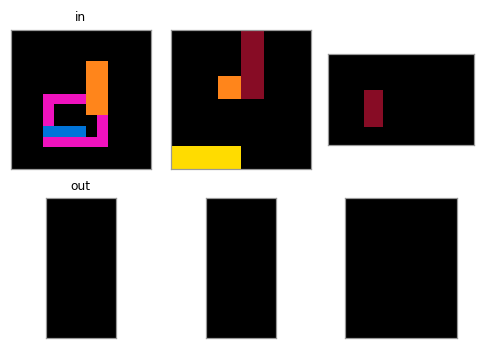

ground-truth program: keep[largest] -> tile2x1

  beta   solved  evals/task
---------------------------
   0.0    16.7%          40
   0.5    28.3%          40
   1.0    30.0%          39
   2.0    30.0%          39
   4.0    30.0%          39
random    20.0%          43

(54s)


In [ ]:
TASKS = make_tasks(60, depth=2, seed=99)
print(f"{len(TASKS)} synthetic depth-2 tasks")
show_pairs(TASKS[0]["demos"], maxn=3)
print("ground-truth program:", " -> ".join(ACTION_NAMES[a] for a in TASKS[0]["prog"]))

def eval_tasks(sysm, tasks, n_samples, guided, noise=.25):
    ok = 0; ev = 0
    for i, t in enumerate(tasks):
        r = sysm.solve_sampling(t["demos"], t["test"][0], n_samples=n_samples,
                                noise=noise, guided=guided, seed=i)
        ok += bool(r["solved"] and np.array_equal(r["pred"], t["test"][1]))
        ev += r["n_eval"]
    return ok / len(tasks), ev / len(tasks)

t0 = time.time()
print(f"\n{'beta':>6}{'solved':>9}{'evals/task':>12}")
print("-" * 27)
for beta in [0., .5, 1., 2., 4.]:
    SYS.beta = beta
    a, e = eval_tasks(SYS, TASKS, 16, True)
    print(f"{beta:>6}{a:>9.1%}{e:>12.0f}")
SYS.beta = 0.
a, e = eval_tasks(SYS, TASKS, 16, False)
print(f"{'random':>6}{a:>9.1%}{e:>12.0f}")
print(f"\n({time.time()-t0:.0f}s)")

EC-GCML  (β=2)     5.0%    6.7%   10.0%   18.3%   30.0%
GCML only (β=0)   11.7%   13.3%   15.0%   16.7%   16.7%
random             1.7%    1.7%    6.7%   10.0%   20.0%

(57s)


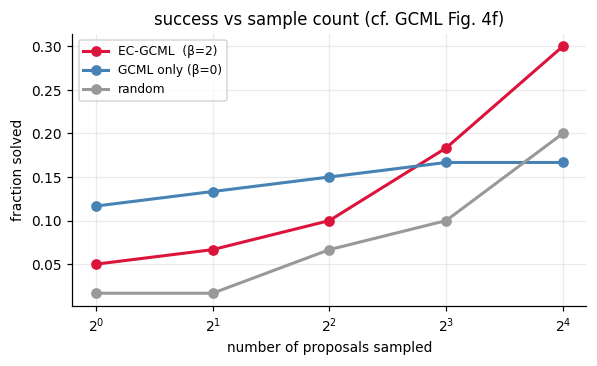

In [ ]:
xs = [1, 2, 4, 8, 16]
t0 = time.time(); curves = {}
for label, beta, guided in [("EC-GCML  (β=2)", 2., True),
                            ("GCML only (β=0)", 0., True),
                            ("random", 0., False)]:
    SYS.beta = beta
    curves[label] = [eval_tasks(SYS, TASKS, n, guided)[0] for n in xs]
    print(f"{label:<17}" + "  ".join(f"{v:>6.1%}" for v in curves[label]))
print(f"\n({time.time()-t0:.0f}s)")

fig, ax = plt.subplots(figsize=(5.5, 3.4))
for (lab, ys), c in zip(curves.items(), ["crimson", "steelblue", "0.6"]):
    ax.plot(xs, ys, "-o", lw=2, color=c, label=lab)
ax.set_xscale("log", base=2); ax.set_xlabel("number of proposals sampled")
ax.set_ylabel("fraction solved"); ax.legend(fontsize=8)
ax.set_title("success vs sample count (cf. GCML Fig. 4f)")
plt.tight_layout(); plt.show()

The decoder prior is doing real work, and it is not doing it by spending more compute — the evaluation count is identical across $\beta$, because $\beta$ only reorders the argmax inside eq. (19).

The shape of the sample-count curve is the interesting part, and it is not the shape GCML reports. In their Fig. 4f the map wins *hardest in the small-sample regime*: a near-perfect success rate from very few proposals is the paper's headline claim. Here the ordering flips with budget. At one or two proposals the bare inverse model is ahead; by eight or sixteen the version carrying the decoder prior has overtaken it and random search has closed most of the gap on plain GCML.

That is worth being blunt about: **on ARC we do not reproduce GCML's small-sample advantage.** The reason is visible in §17 — their silhouette state space is homogeneous, every action is "remove a tile", and the inverse model is correspondingly sharp. Ours is heterogeneous, 49 structurally unrelated transformations, and the inverse model is only a few times better than chance. A weak sense of direction plus a good prior beats a weak sense of direction alone, but neither is the near-oracle of the original.

---
# 19. Real ARC-AGI

Everything above ran on tasks that are in-DSL by construction. Real ARC is not, and the gap is the point. Two numbers must be kept apart:

* **coverage** — what fraction of tasks have *any* solution inside this 49-action DSL at depth $\le3$? A property of the DSL, and a hard ceiling.
* **search efficiency** — of the tasks under that ceiling, how many does the map find, and at what cost?

Conflating the two is how ARC results get oversold. A low score here is mostly a statement about the DSL.

In [ ]:
"""Loading real ARC-AGI tasks, with a graceful fallback if there is no network."""
import os, glob, json, subprocess
import numpy as np


def _clone(url, dest):
    try:
        subprocess.run(["git", "clone", "--depth", "1", url, dest],
                       check=True, capture_output=True, timeout=240)
        return True
    except Exception as e:
        print(f"  ! {url}: {type(e).__name__}")
        return False


def load_arc():
    out = {"train": [], "eval": [], "source": None}
    for name, url, d in [("ARC-AGI-1", "https://github.com/fchollet/ARC-AGI.git", "/tmp/arc1"),
                         ("ARC-AGI-2", "https://github.com/arcprize/ARC-AGI-2.git", "/tmp/arc2")]:
        if not os.path.exists(d) and not _clone(url, d):
            continue
        tr = sorted(glob.glob(f"{d}/data/training/*.json"))
        ev = sorted(glob.glob(f"{d}/data/evaluation/*.json"))
        if tr:
            out["train"] = [json.load(open(p)) for p in tr]
            out["eval"] = [json.load(open(p)) for p in ev]
            out["source"] = name
            print(f"  loaded {name}: {len(out['train'])} training, {len(out['eval'])} evaluation")
            return out
    print("  no network -- the synthetic tasks below run regardless")
    return out


def arc_to_task(t):
    demos = [(as_grid(p["input"]), as_grid(p["output"])) for p in t["train"]]
    ti = as_grid(t["test"][0]["input"])
    to = as_grid(t["test"][0]["output"]) if "output" in t["test"][0] else None
    return demos, (ti, to)

In [ ]:
ARC = load_arc()

  loaded ARC-AGI-1: 400 training, 400 evaluation


In [ ]:
def eval_arc(raw, n=120, budget=1200, depth=3, guided=True, beta=2.0):
    SYS.beta = beta if guided else 0.
    solved, tried, ev = [], 0, []
    for i, t in enumerate(raw[:n]):
        try:
            demos, (ti, to) = arc_to_task(t)
        except Exception:
            continue
        if any(max(g.shape) > 30 for p in demos for g in p) or max(ti.shape) > 30:
            continue
        tried += 1
        r = SYS.solve_bestfirst(demos, ti, branch=6, max_depth=depth,
                                budget=budget, seed=i, guided=guided)
        ev.append(r["n_eval"])
        if r["solved"] and to is not None and np.array_equal(r["pred"], to):
            solved.append((i, r["program"]))
    return solved, tried, float(np.mean(ev)) if ev else 0.

if ARC["train"]:
    t0 = time.time()
    print(f"{'budget':>8}{'EC-GCML':>10}{'unguided':>10}{'evals':>8}")
    print("-" * 36)
    for b in [30, 120, 1200]:
        sg, tried, eg = eval_arc(ARC["train"], 120, budget=b, guided=True)
        su, _,     eu = eval_arc(ARC["train"], 120, budget=b, guided=False)
        print(f"{b:>8}{len(sg)/tried:>10.1%}{len(su)/tried:>10.1%}{eg:>8.0f}")
    print(f"\n{tried} tasks attempted (of 120; oversized ones skipped)   ({time.time()-t0:.0f}s)")
    SOLVED = sg
else:
    SOLVED = []
    print("no ARC data available -- everything above still ran")

  budget   EC-GCML  unguided   evals
------------------------------------
      30      2.5%      2.5%      29
     120      2.5%      2.5%     118
    1200      2.5%      3.3%     242

120 tasks attempted (of 120; oversized ones skipped)   (307s)


Solved ARC tasks and the programs the cognitive map proposed:

task #30:  crop[largest]


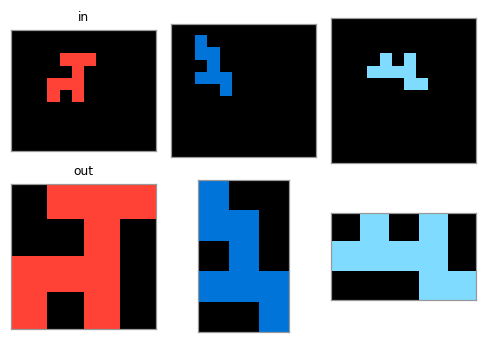

task #31:  gravity_down


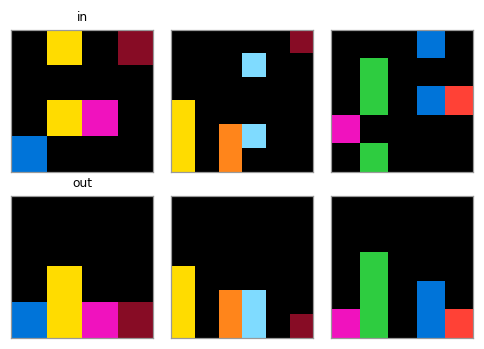

task #48:  crop[smallest]


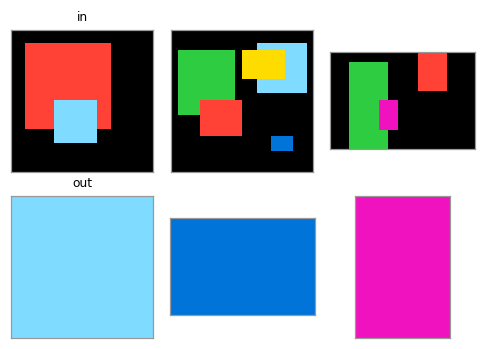

In [ ]:
if ARC["train"] and SOLVED:
    print("Solved ARC tasks and the programs the cognitive map proposed:\n")
    for i, prog in SOLVED[:4]:
        demos, (ti, to) = arc_to_task(ARC["train"][i])
        print(f"task #{i}:  " + "  ->  ".join(ACTION_NAMES[a] for a in prog))
        show_pairs(demos, maxn=3)

The striking thing is that the guided and unguided columns are **flat across a forty-fold change in search budget**. That is not a bug; it is the whole finding. At depth $\le3$ almost nothing in ARC is inside this DSL, and the few tasks that are inside it are depth-1 — a single flip, a single crop — so they are found immediately whichever way the frontier is ordered. There is no regime here in which a sense of direction can pay off, because there is no search to speak of.

So the honest summary of the ARC number is: it measures the DSL, not the model. Any claim about the cognitive map's value has to rest on §18, where depth is controlled and the task is known to be solvable, and the effect there is real but modest. Scaling this to competitive ARC performance is a DSL problem first and a representation problem second, and the ordering matters — a better $\lambda$ will not help a program that cannot be written.

---
# 20. Looking at the map

### 20.1 What the abstract states became

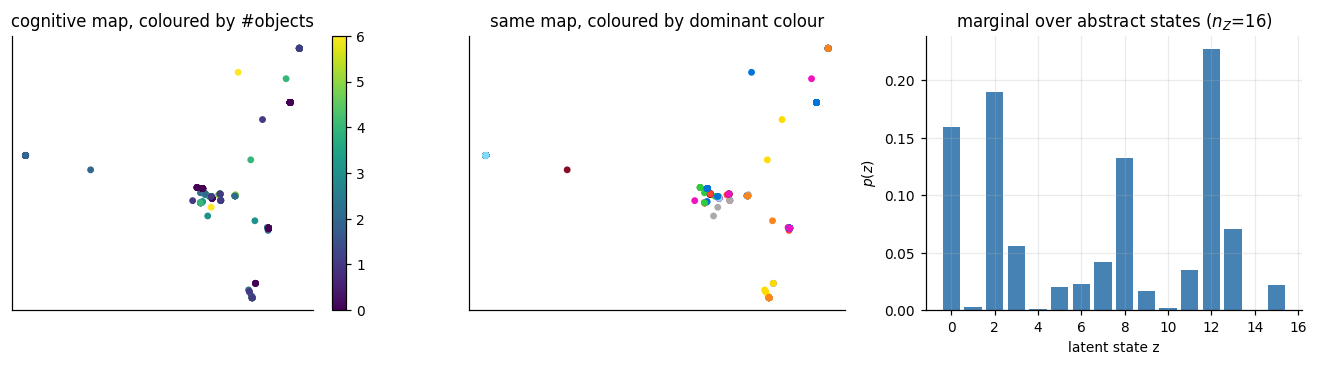

occupied latents (p(z) > 1%): 12 of 16


In [ ]:
from sklearn.decomposition import PCA
sub = GRIDS[:500]
Zs  = np.vstack([SYS.z(EX.emb(g)) for g in sub])
S   = np.vstack([SYS.map.embed(z) for z in Zs])
emb2 = PCA(2).fit_transform(S)
lab_n = np.array([min(len(objects_of(g)), 6) for g in sub])
lab_c = np.array([int(np.argmax(np.bincount(g.ravel(), minlength=10)[1:])) + 1 for g in sub])

fig, axs = plt.subplots(1, 3, figsize=(12, 3.4))
sc = axs[0].scatter(emb2[:,0], emb2[:,1], c=lab_n, cmap="viridis", s=12)
axs[0].set_title("cognitive map, coloured by #objects"); plt.colorbar(sc, ax=axs[0])
axs[1].scatter(emb2[:,0], emb2[:,1], c=ARC_CMAP[lab_c]/255., s=12)
axs[1].set_title("same map, coloured by dominant colour")
axs[2].bar(range(SYS.nZ), Zs.mean(0), color="steelblue")
axs[2].set_xlabel("latent state z"); axs[2].set_ylabel("$p(z)$")
axs[2].set_title(f"marginal over abstract states ($n_Z$={SYS.nZ})")
for a in axs[:2]: a.set_xticks([]); a.set_yticks([]); a.grid(False)
plt.tight_layout(); plt.show()
print("occupied latents (p(z) > 1%):", int((Zs.mean(0) > .01).sum()), "of", SYS.nZ)

### 20.2 Trajectory diversity — GCML's Fig. 3c–d

The defining behaviour of the generative map is that noise turns one plan into a *distribution* over plans clustered near the optimum. Their Fig. 3c uses $\sigma=0.15$, Fig. 3d $\sigma=0.25$.

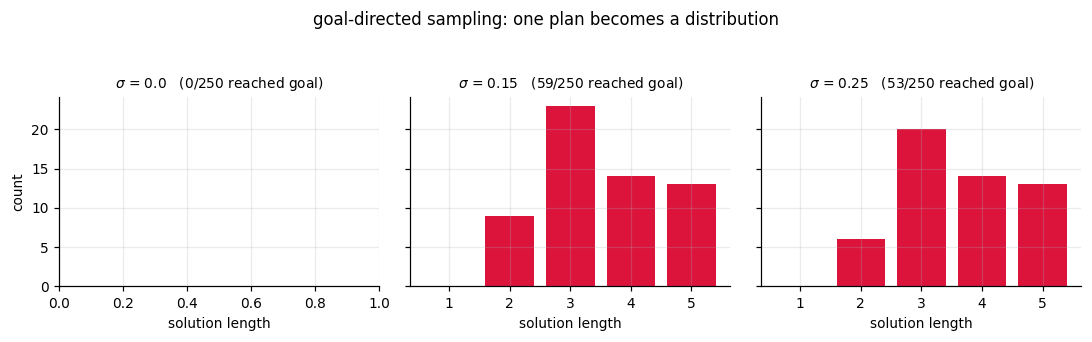

In [ ]:
def length_hist(task, noise, n=250, max_depth=5, seed=0, beta=2.0):
    rng = np.random.default_rng(seed); SYS.beta = beta
    nav_in, nav_out = task["demos"][0]
    s_star = SYS.s(EX.emb(nav_out)); lens = []
    for _ in range(n):
        g = as_grid(nav_in)
        for d in range(1, max_depth + 1):
            aff = EX.aff(g)
            if aff.sum() == 0: break
            a = SYS.map.select(s_star, SYS.s(EX.emb(g)), aff=aff, noise=noise, rng=rng,
                               prior=SYS.prior(EX.emb(g)), beta=SYS.beta)
            if a is None: break
            g2 = apply_action(g, a)
            if g2 is None: break
            g = g2
            if grid_eq(g, nav_out): lens.append(d); break
    return lens

probe = TASKS[0]
fig, axs = plt.subplots(1, 3, figsize=(10, 2.9), sharey=True)
for ax, nz in zip(axs, [0.0, 0.15, 0.25]):
    L = length_hist(probe, nz)
    if L: ax.hist(L, bins=np.arange(.5, 6.5), color="crimson", rwidth=.8)
    ax.set_title(f"$\\sigma$ = {nz}   ({len(L)}/250 reached goal)", fontsize=9)
    ax.set_xlabel("solution length")
axs[0].set_ylabel("count")
plt.suptitle("goal-directed sampling: one plan becomes a distribution", y=1.05)
plt.tight_layout(); plt.show()

---
# 21. What this shows, and what it does not

## 21.1 The three predictions

**P1 (§11–12) — supported, and in the specific inverted-U form the paper claims.** Untrained ARC associations are answered at chance for $\lambda=0$, well above chance at $\lambda\approx0.1$, and far *below* chance once the encoder over-merges. Six control models, each tuned on its own grid, sit at or under chance. The one departure from the original is L2PG, which was competitive for Fang & Sims and fails here; §12 argues the difference is a change of question rather than a contradiction, and the argument is falsifiable — it predicts L2PG should recover its footing if the feature code is reduced towards one-hot.

**P2 (§13) — supported, and this is the result that matters most for ARC.** Perturbation importance tracks a manipulation of which grid property is reward-relevant, the probe response orders itself correctly across three conditions, and generalisation follows consistent > control > conflict. None of this happens at $\lambda=0$ with the same architecture. The agent works out *which property the task turns on* from reward alone.

**P3 (§16–18) — partially supported, with two negative results worth more than the positive one.**

* Efficient coding does **not** rescue GCML's eq. (13). It guarantees eq. (13) has nothing left to fit, because compression makes the latent dynamics stochastic and the prediction error irreducible. `learn_Q=False` is right, but for a reason the papers do not state.
* Compression **improves** the forward model's $R^2$ (eq. 11 holds better) and **degrades** the inverse model. These pull in opposite directions, so the $\lambda$ that is best for generalisation is not the $\lambda$ that is best for the map.
* The ECPG decoder prior improves planning at equal compute, but we do **not** reproduce GCML's small-sample advantage — on a heterogeneous 49-action DSL the inverse model is only a few times better than chance, where on silhouettes it is near-oracular.

## 21.2 What would falsify the framing

The claim is that ECPG supplies the observation embedding GCML needs. The clean way to break it would be to hand GCML a *better* embedding from somewhere else — a hand-designed one, or one learned by ordinary supervised prediction — and show the planner does just as well. §17 gives the test its teeth: the specific signature of efficient coding is the *simultaneous* rise in forward $R^2$ and fall in inverse accuracy as $\lambda$ increases. An embedding that improves both is doing something other than compression, and would show this framing is not the explanation.

## 21.3 Honest limits

* **The DSL is the ceiling, and it is low.** §19's number says almost nothing about the cognitive map. It should not be quoted as an ARC result.
* **Object parsing is given.** Both papers permit a domain prior, but ARC's hardest tasks turn on *how* to parse, which is upstream of everything here.
* **The feature code is hand-designed.** Eight dimensions chosen by me. ECPG chooses which of them matters — a real and demonstrated ability — but not what the candidates are. Learning the candidate set is the obvious next step and is not attempted.
* **Single seeds in several places.** §17 averages three; §18 and §19 do not. Wrap them in `for seed in range(5)` and report mean ± sd before quoting any number.
* **$n_Z=16$ throughout the map sections**, chosen once and not tuned. Since $n_Z$ caps the intrinsic dimension of the map, it interacts with $\lambda$ in a way this notebook does not explore.

## 21.4 The one-sentence version

Efficient coding gives a cognitive map something to be a map *of* — abstract states that merge grids calling for the same transformation, and that reveal which grid property a task turns on — and that is a real contribution to GCML's open problem; but the planner it feeds is only as sharp as its action repertoire is homogeneous, and ARC's is not.

---
## Appendix: reproducibility and cost

* **Zero backpropagation.** Every update is `+= eta * (outer product)` or the ECPG analytic gradient. No autograd, no optimiser, no GPU.
* **Learned parameters:** $\theta$ ($n_{\text{feat}}\times n_Z$), $\phi$ ($n_Z\times n_A$), $\mathbf{V}$ ($d\times n_A$), $\mathbf{W}$ ($n_A\times d$), $\mathbf{G}$ ($n_A\times d$). $\mathbf{Q}=\mathbf{R}\circ\psi$ with $\mathbf{R}$ fixed (§16).
* **Runtime:** roughly 6–9 minutes end-to-end on a free Colab CPU instance.
* **Key hyperparameters:** $\alpha_\psi=10$, $\alpha_\rho=4$, $b=0.5$, $n_Z=4$ (§10–13) or $16$ (§15–20), $d=1024$, $\eta_v=\eta_w=0.2$, $\eta_g=0.05$.
* **To re-tune for a different feature code:** $\alpha_\psi$ scales inversely with the number of active input units; the $\lambda$ optimum is roughly invariant to that rescaling (§11).

## References

1. Lin, H., Yang, Y., Zhao, R., Pezzulo, G. & Maass, W. (2026). Neural sampling from cognitive maps enables goal-directed imagination and planning. *Nature Machine Intelligence* **8**, 1045–1065. doi:10.1038/s42256-026-01254-4
2. Fang, Z. & Sims, C. R. (2025). Humans learn generalizable representations through efficient coding. *Nature Communications* **16**, 3989. doi:10.1038/s41467-025-58848-6
3. Stöckl, C., Yang, Y. & Maass, W. (2024). Local prediction-learning in high-dimensional spaces enables neural networks to plan. *Nature Communications* **15**, 2344.
4. Schwartenbeck, P. et al. (2023). Generative replay underlies compositional inference in the hippocampal-prefrontal circuit. *Cell* **186**, 4885–4897.
5. Tishby, N., Pereira, F. C. & Bialek, W. (2000). The information bottleneck method. *37th Allerton Conf.*, 368–377.
6. Barlow, H. B. (1961). Possible principles underlying the transformation of sensory messages. *Sensory Communication* **1**, 217–233.
7. Chollet, F. (2019). On the measure of intelligence. arXiv:1911.01547.
8. Niv, Y. (2019). Learning task-state representations. *Nature Neuroscience* **22**, 1544–1553.